## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [228]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [229]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn import metrics

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
#%load_ext nb_black

## Loading the dataset

In [230]:
df_train = pd.read_csv("/content/drive/MyDrive/DSBA program/6. Model Tuning/Train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/DSBA program/6. Model Tuning/Test.csv")

## Data Overview

- Observations
- Sanity checks

In [231]:
# See if datasets were loaded properly:
df_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.465,-4.679,3.102,0.506,-0.221,-2.033,-2.911,0.051,-1.522,3.762,-5.715,0.736,0.981,1.418,-3.376,-3.047,0.306,2.914,2.270,4.395,-2.388,0.646,-1.191,3.133,0.665,-2.511,-0.037,0.726,-3.982,-1.073,1.667,3.060,-1.690,2.846,2.235,6.667,0.444,-2.369,2.951,-3.480,0
1,3.366,3.653,0.910,-1.368,0.332,2.359,0.733,-4.332,0.566,-0.101,1.914,-0.951,-1.255,-2.707,0.193,-4.769,-2.205,0.908,0.757,-5.834,-3.065,1.597,-1.757,1.766,-0.267,3.625,1.500,-0.586,0.783,-0.201,0.025,-1.795,3.033,-2.468,1.895,-2.298,-1.731,5.909,-0.386,0.616,0
2,-3.832,-5.824,0.634,-2.419,-1.774,1.017,-2.099,-3.173,-2.082,5.393,-0.771,1.107,1.144,0.943,-3.164,-4.248,-4.039,3.689,3.311,1.059,-2.143,1.650,-1.661,1.680,-0.451,-4.551,3.739,1.134,-2.034,0.841,-1.600,-0.257,0.804,4.086,2.292,5.361,0.352,2.940,3.839,-4.309,0
3,1.618,1.888,7.046,-1.147,0.083,-1.530,0.207,-2.494,0.345,2.119,-3.053,0.460,2.705,-0.636,-0.454,-3.174,-3.404,-1.282,1.582,-1.952,-3.517,-1.206,-5.628,-1.818,2.124,5.295,4.748,-2.309,-3.963,-6.029,4.949,-3.584,-2.577,1.364,0.623,5.550,-1.527,0.139,3.101,-1.277,0
4,-0.111,3.872,-3.758,-2.983,3.793,0.545,0.205,4.849,-1.855,-6.220,1.998,4.724,0.709,-1.989,-2.633,4.184,2.245,3.734,-6.313,-5.380,-0.887,2.062,9.446,4.490,-3.945,4.582,-8.780,-3.383,5.107,6.788,2.044,8.266,6.629,-10.069,1.223,-3.230,1.687,-2.164,-3.645,6.510,0


In [232]:
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613,-3.820,2.202,1.300,-1.185,-4.496,-1.836,4.723,1.206,-0.342,-5.123,1.017,4.819,3.269,-2.984,1.387,2.032,-0.512,-1.023,7.339,-2.242,0.155,2.054,-2.772,1.851,-1.789,-0.277,-1.255,-3.833,-1.505,1.587,2.291,-5.411,0.870,0.574,4.157,1.428,-10.511,0.455,-1.448,0
1,0.390,-0.512,0.527,-2.577,-1.017,2.235,-0.441,-4.406,-0.333,1.967,1.797,0.410,0.638,-1.390,-1.883,-5.018,-3.827,2.418,1.762,-3.242,-3.193,1.857,-1.708,0.633,-0.588,0.084,3.014,-0.182,0.224,0.865,-1.782,-2.475,2.494,0.315,2.059,0.684,-0.485,5.128,1.721,-1.488,0
2,-0.875,-0.641,4.084,-1.590,0.526,-1.958,-0.695,1.347,-1.732,0.466,-4.928,3.565,-0.449,-0.656,-0.167,-1.630,2.292,2.396,0.601,1.794,-2.120,0.482,-0.841,1.790,1.874,0.364,-0.169,-0.484,-2.119,-2.157,2.907,-1.319,-2.997,0.460,0.620,5.632,1.324,-1.752,1.808,1.676,0
3,0.238,1.459,4.015,2.534,1.197,-3.117,-0.924,0.269,1.322,0.702,-5.578,-0.851,2.591,0.767,-2.391,-2.342,0.572,-0.934,0.509,1.211,-3.260,0.105,-0.659,1.498,1.100,4.143,-0.248,-1.137,-5.356,-4.546,3.809,3.518,-3.074,-0.284,0.955,3.029,-1.367,-3.412,0.906,-2.451,0
4,5.828,2.768,-1.235,2.809,-1.642,-1.407,0.569,0.965,1.918,-2.775,-0.530,1.375,-0.651,-1.679,-0.379,-4.443,3.894,-0.608,2.945,0.367,-5.789,4.598,4.450,3.225,0.397,0.248,-2.362,1.079,-0.473,2.243,-3.591,1.774,-1.502,-2.227,4.777,-6.560,-0.806,-0.276,-3.858,-0.538,0


In [233]:
# Check the size of the training dataframe:
df_train.shape

(20000, 41)

We observe there are 20000 rows and 41 columns in the training dataset.

In [234]:
# Check the number of rows and columns of the test set:
df_test.shape

(5000, 41)

In [235]:
# Let's make a copy of the training set:
data = df_train.copy()

In [236]:
# Let's make a copy of the test set:
data_test = df_test.copy()

In [237]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

We observe there are 18 missing values in the first two columns.  All columns are floats, except the last column is an integer (no decimal values)

In [238]:
# Let's check for duplicate values:
data.duplicated().sum()

np.int64(0)

In [239]:
data_test.duplicated().sum()

np.int64(0)

In [240]:
# Let's check for missing values in the training data:
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [241]:
# Let's check missing values in the test set:
data_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [242]:
#Let's get a statistical summary of the numerical columns:
data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000,19982.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,-0.272,0.440,2.485,-0.083,-0.054,-0.995,-0.879,-0.548,-0.017,-0.013,-1.895,1.605,1.580,-0.951,-2.415,-2.925,-0.134,1.189,1.182,0.024,-3.611,0.952,-0.366,1.134,-0.002,1.874,-0.612,-0.883,-0.986,-0.016,0.487,0.304,0.050,-0.463,2.230,1.515,0.011,-0.344,0.891,-0.876,0.056
std,3.442,3.151,3.389,3.432,2.105,2.041,1.762,3.296,2.161,2.193,3.124,2.930,2.875,1.790,3.355,4.222,3.345,2.592,3.397,3.669,3.568,1.652,4.032,3.912,2.017,3.435,4.369,1.918,2.684,3.005,3.461,5.500,3.575,3.184,2.937,3.801,1.788,3.948,1.753,3.012,0.229
min,-11.876,-12.320,-10.708,-15.082,-8.603,-10.227,-7.950,-15.658,-8.596,-9.854,-14.832,-12.948,-13.228,-7.739,-16.417,-20.374,-14.091,-11.644,-13.492,-13.923,-17.956,-10.122,-14.866,-16.387,-8.228,-11.834,-14.905,-9.269,-12.579,-14.796,-13.723,-19.877,-16.898,-17.985,-15.350,-14.833,-5.478,-17.375,-6.439,-11.024,0.000
25%,-2.737,-1.641,0.207,-2.348,-1.536,-2.347,-2.031,-2.643,-1.495,-1.411,-3.922,-0.397,-0.224,-2.171,-4.415,-5.634,-2.216,-0.404,-1.050,-2.433,-5.930,-0.118,-3.099,-1.468,-1.365,-0.338,-3.652,-2.171,-2.787,-1.867,-1.818,-3.420,-2.243,-2.137,0.336,-0.944,-1.256,-2.988,-0.272,-2.940,0.000
50%,-0.748,0.472,2.256,-0.135,-0.102,-1.001,-0.917,-0.389,-0.068,0.101,-1.921,1.508,1.637,-0.957,-2.383,-2.683,-0.015,0.883,1.279,0.033,-3.533,0.975,-0.262,0.969,0.025,1.951,-0.885,-0.891,-1.176,0.184,0.490,0.052,-0.066,-0.255,2.099,1.567,-0.128,-0.317,0.919,-0.921,0.000
75%,1.840,2.544,4.566,2.131,1.340,0.380,0.224,1.723,1.409,1.477,0.119,3.571,3.460,0.271,-0.359,-0.095,2.069,2.572,3.493,2.512,-1.266,2.026,2.452,3.546,1.397,4.130,2.189,0.376,0.630,2.036,2.731,3.762,2.255,1.437,4.064,3.984,1.176,2.279,2.058,1.120,0.000
max,15.493,13.089,17.091,13.236,8.134,6.976,8.006,11.679,8.138,8.108,11.826,15.081,15.420,5.671,12.246,13.583,16.756,13.180,13.238,16.052,13.840,7.410,14.459,17.163,8.223,16.836,17.560,6.528,10.722,12.506,17.255,23.633,16.692,14.358,15.291,19.330,7.467,15.290,7.760,10.654,1.000


## Exploratory Data Analysis (EDA)

### Plotting histograms and boxplots for all the variables

In [243]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Plotting all the features at one go

CPU times: user 9.95 s, sys: 68 ms, total: 10 s
Wall time: 10.1 s


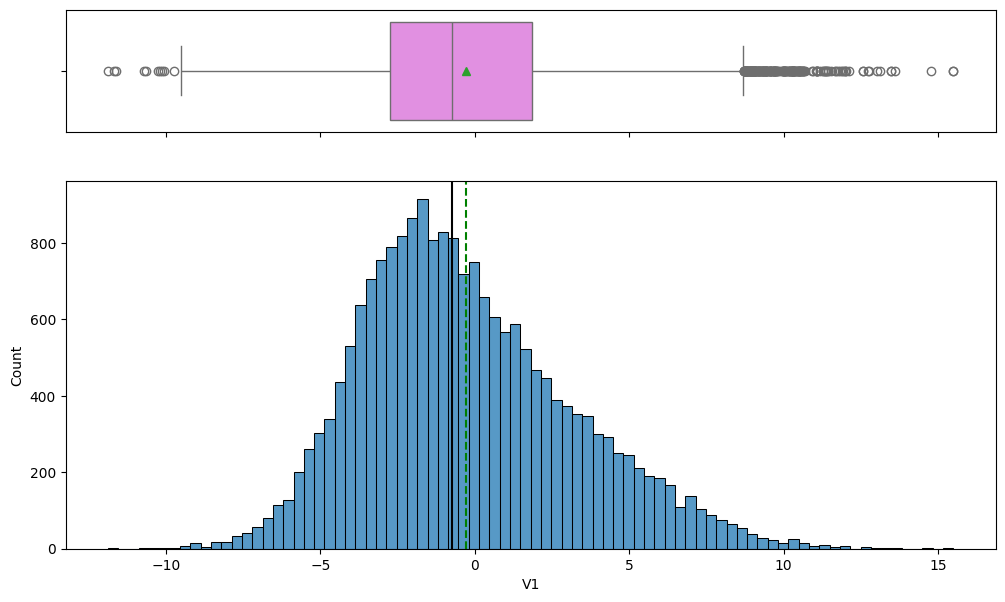

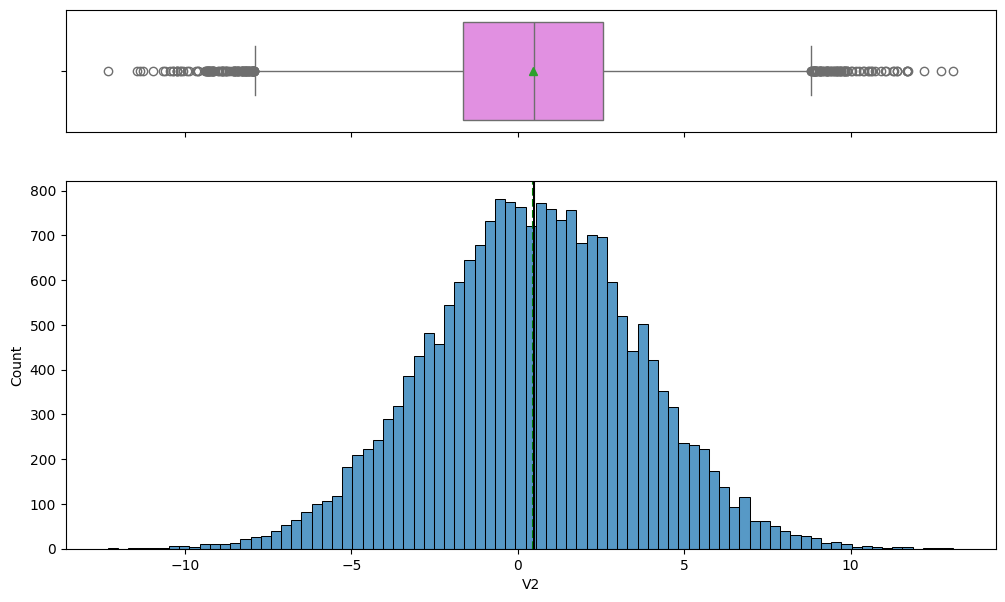

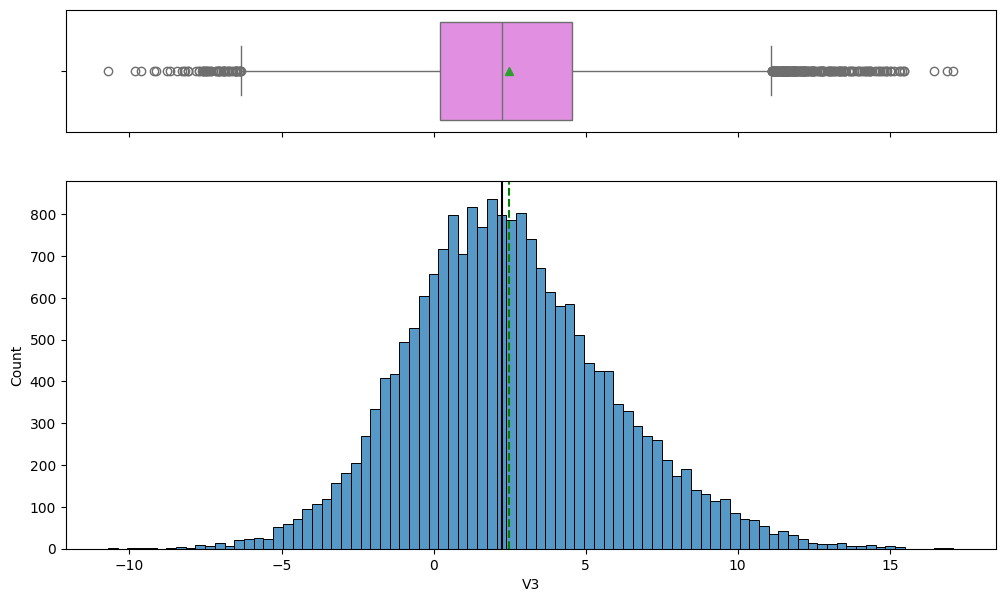

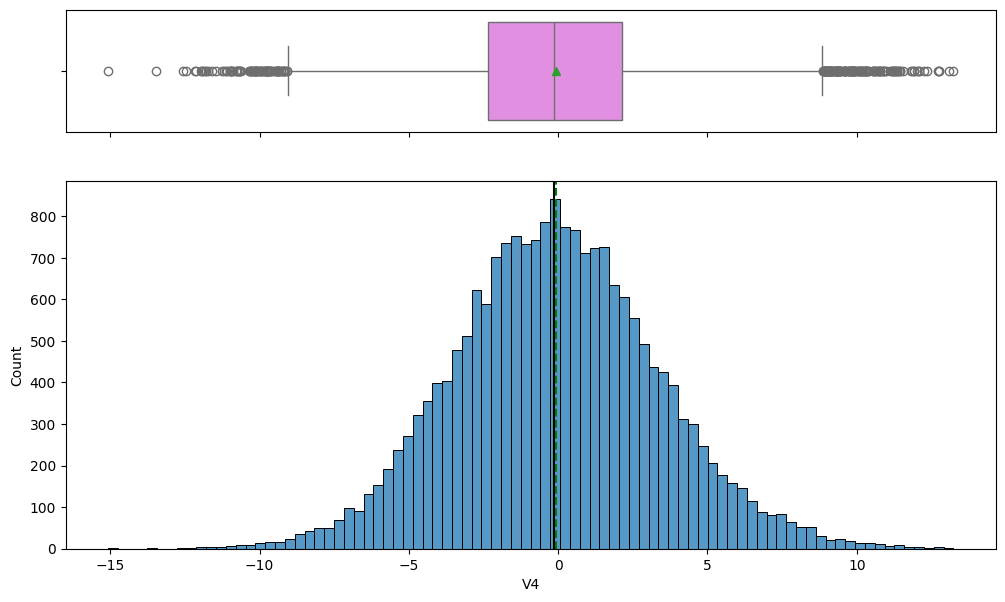

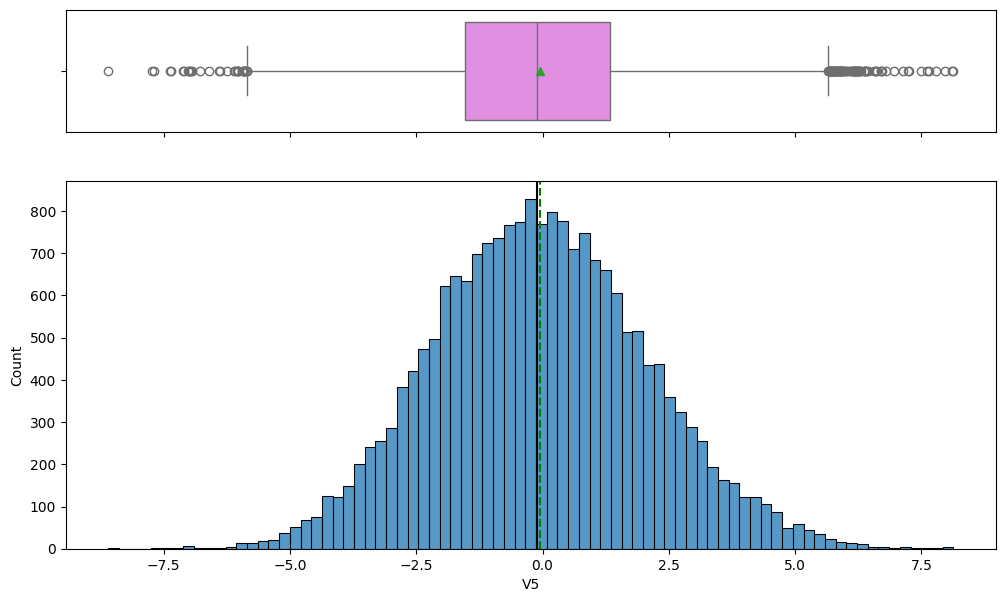

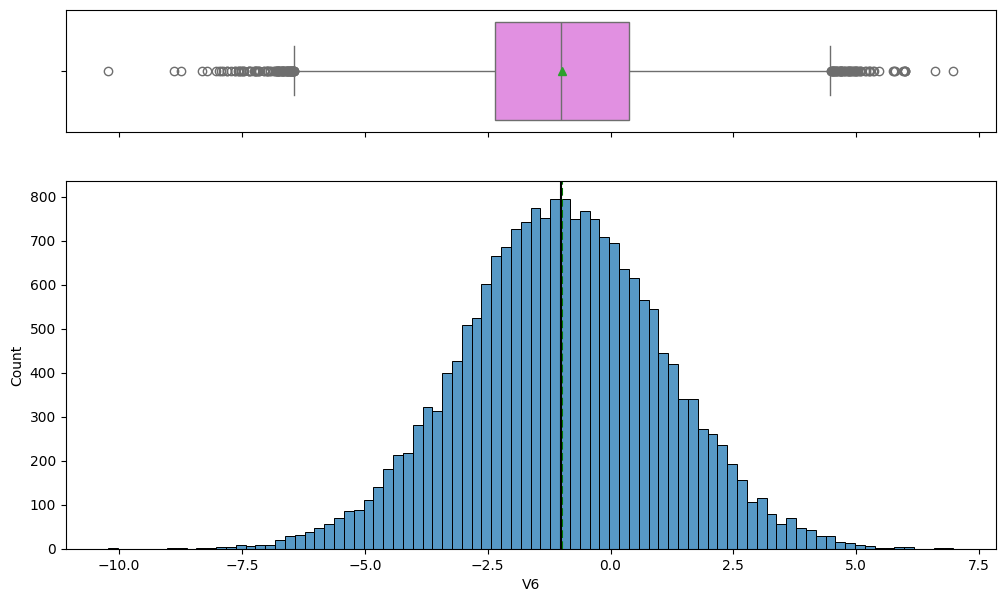

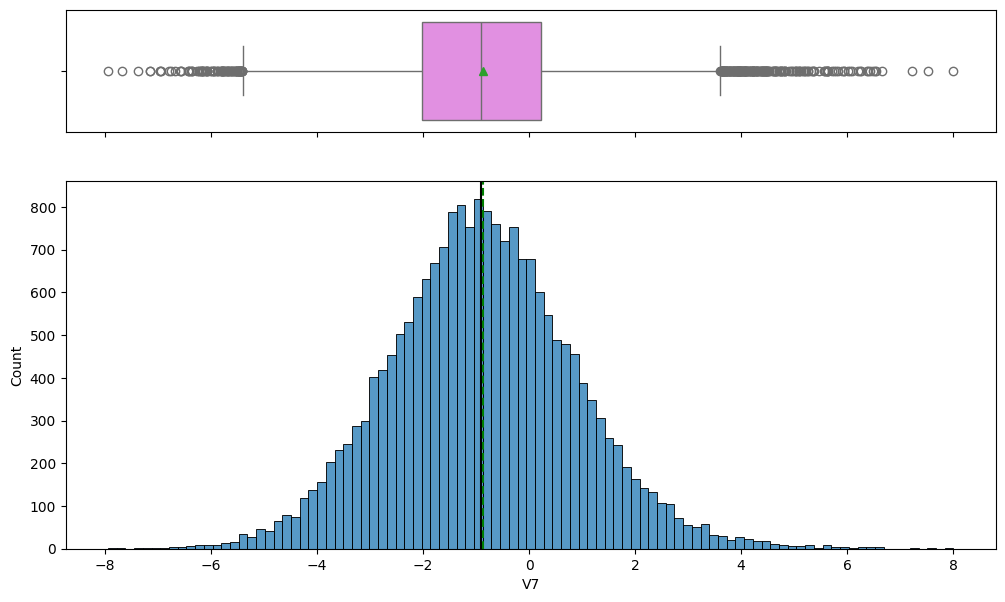

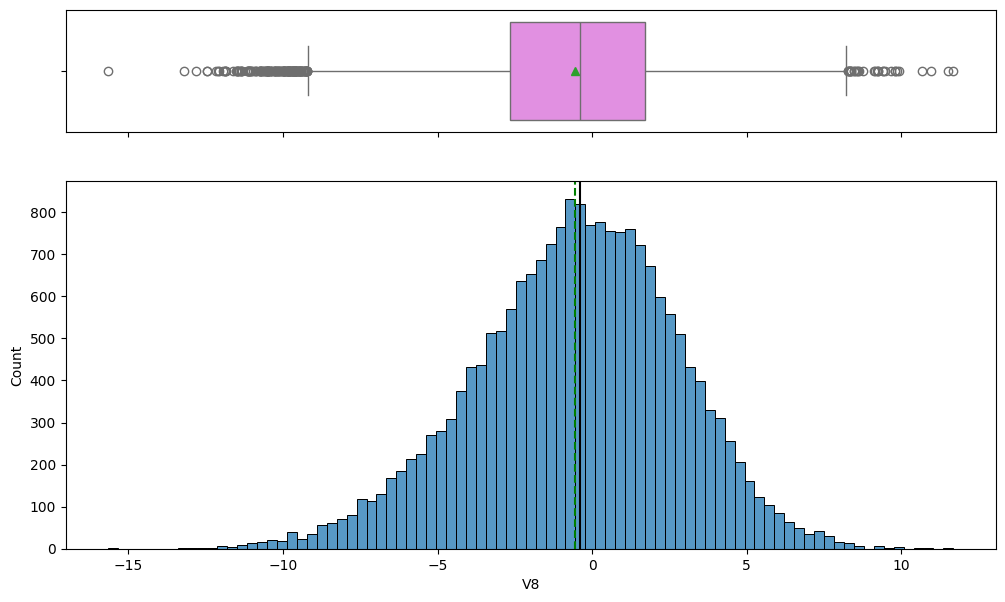

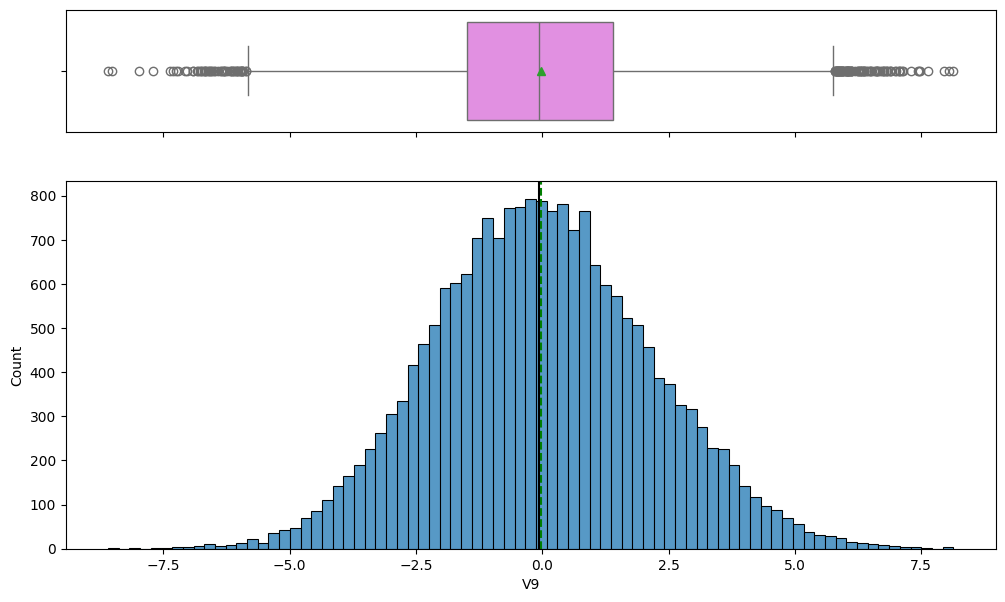

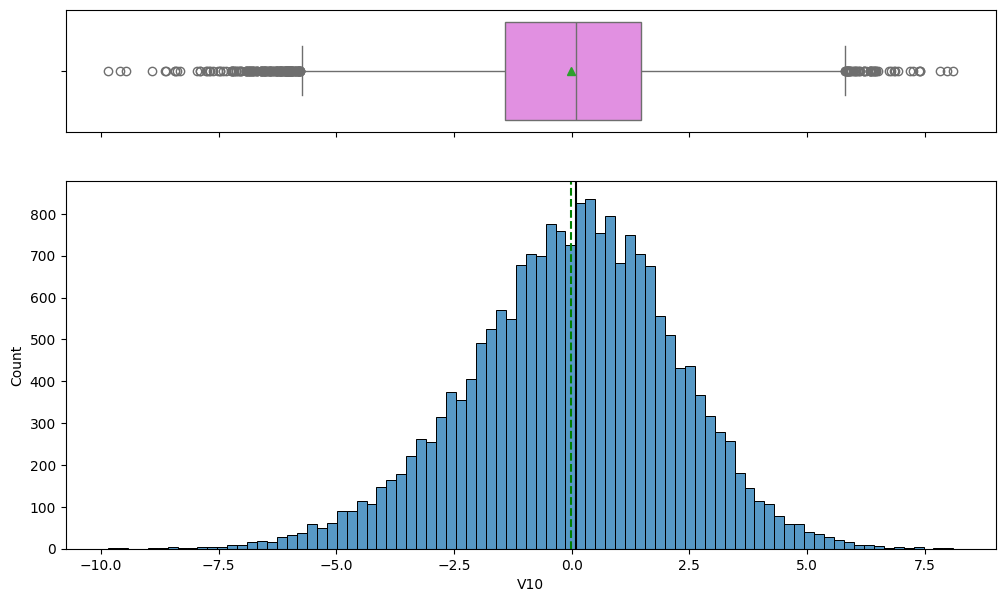

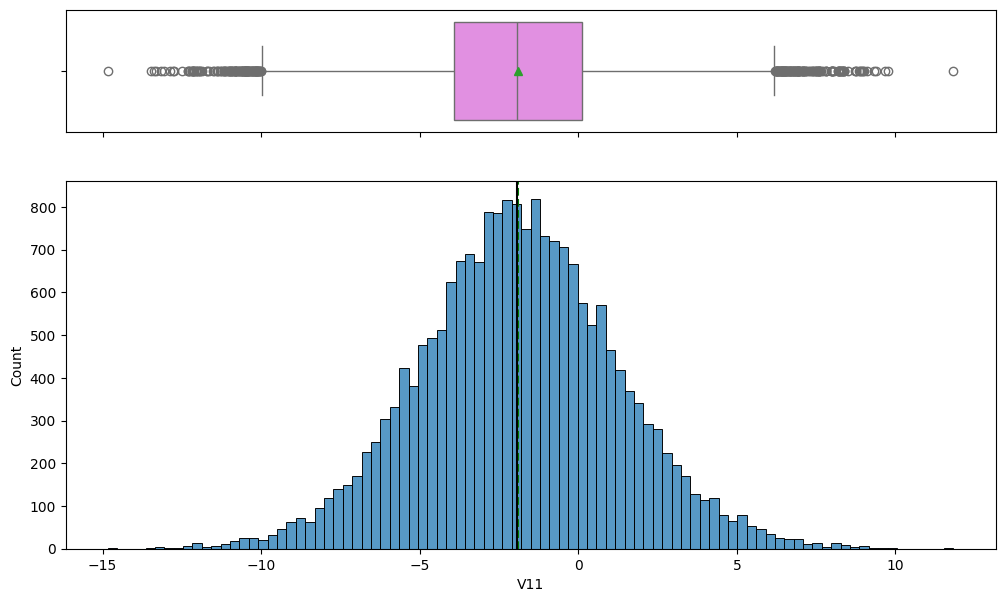

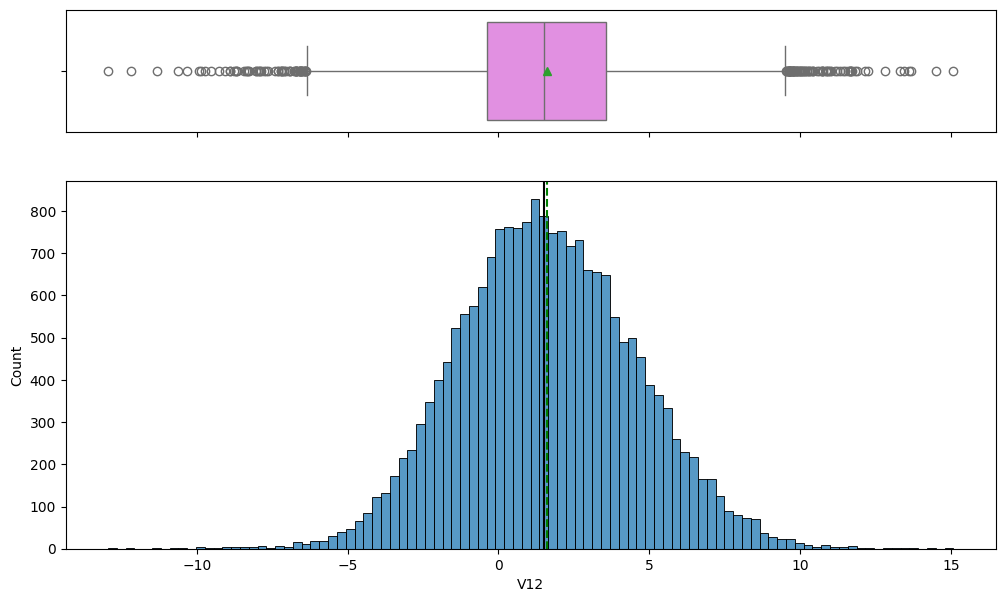

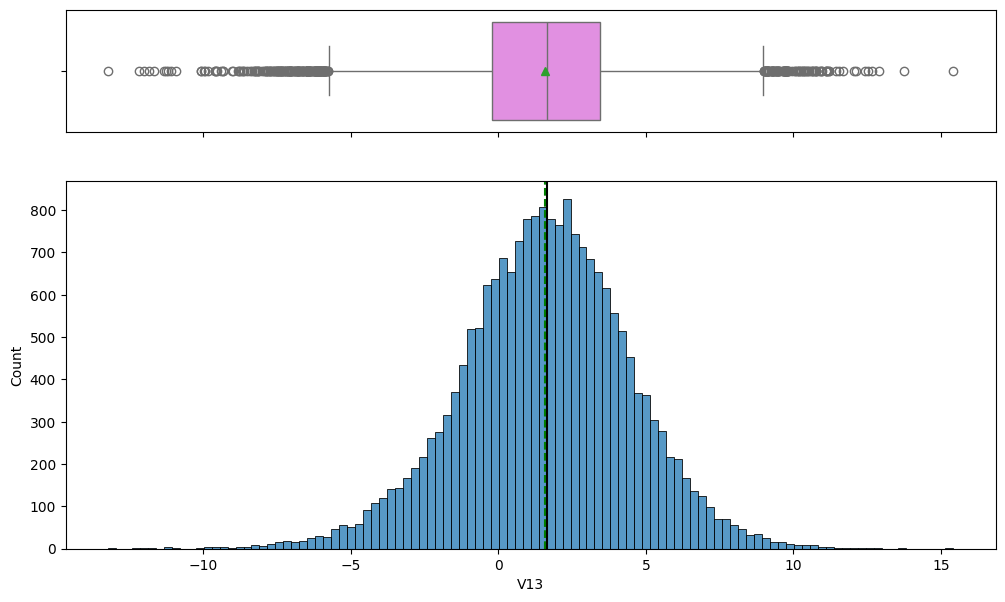

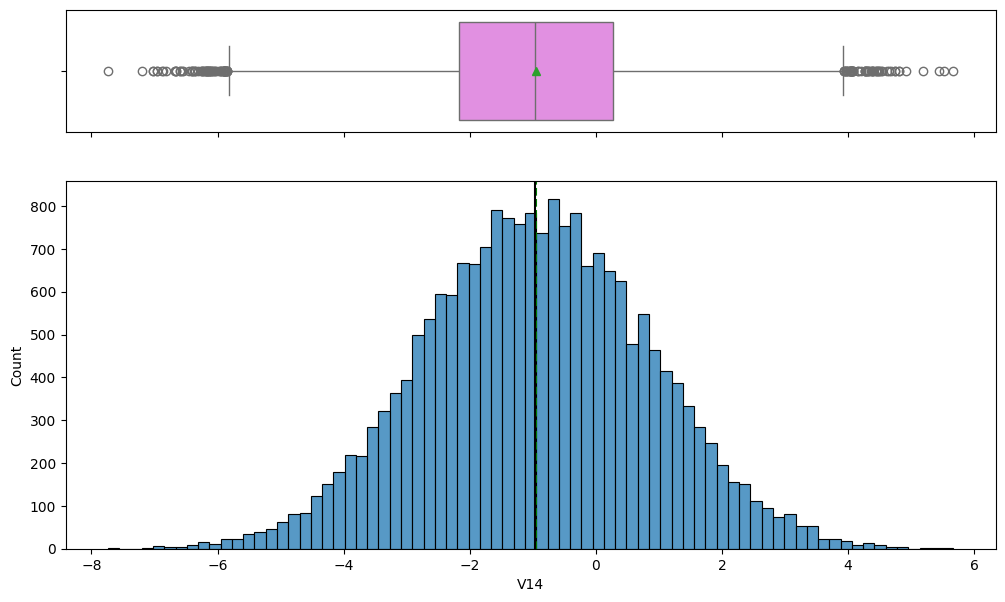

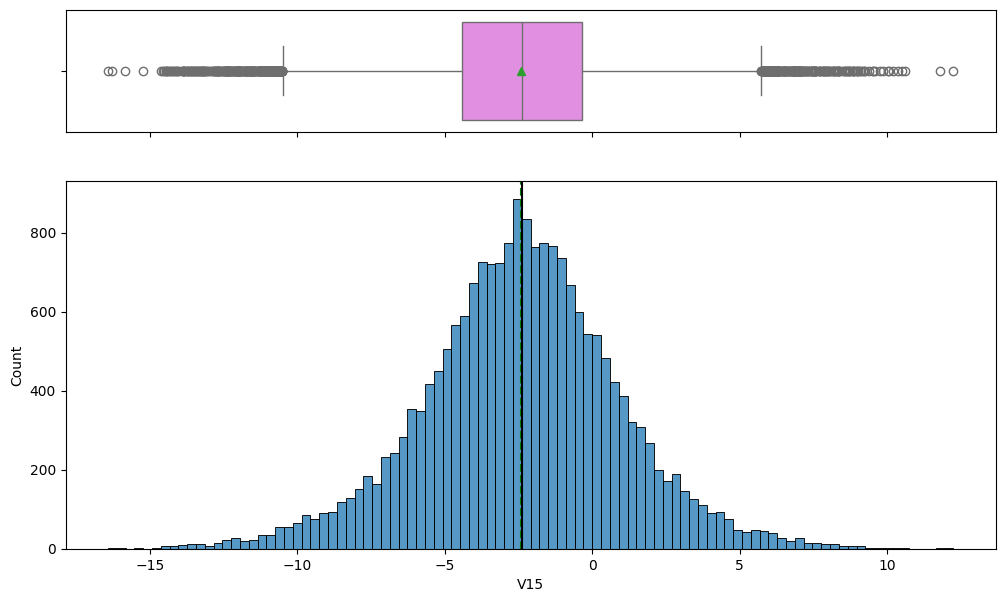

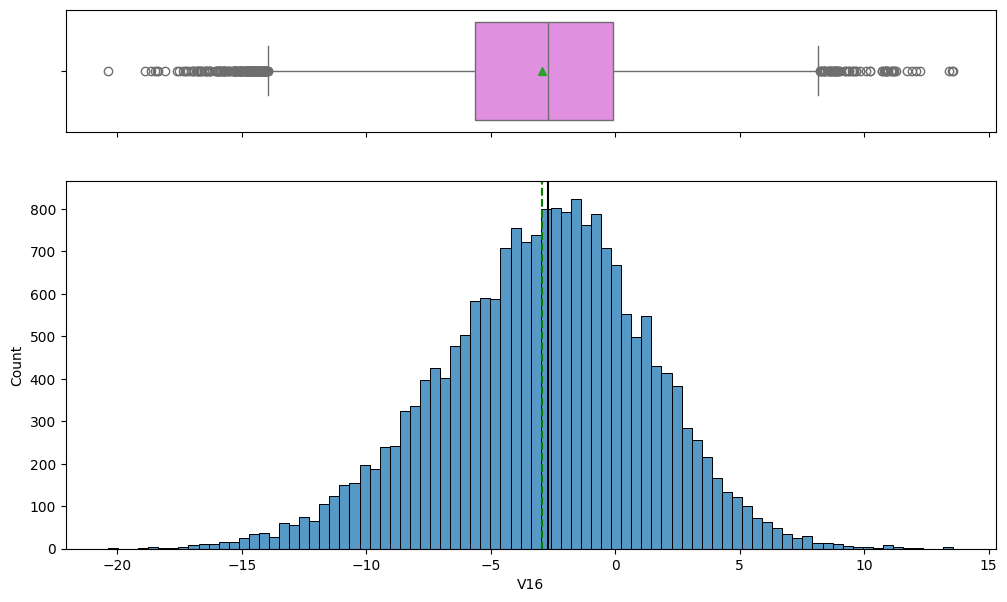

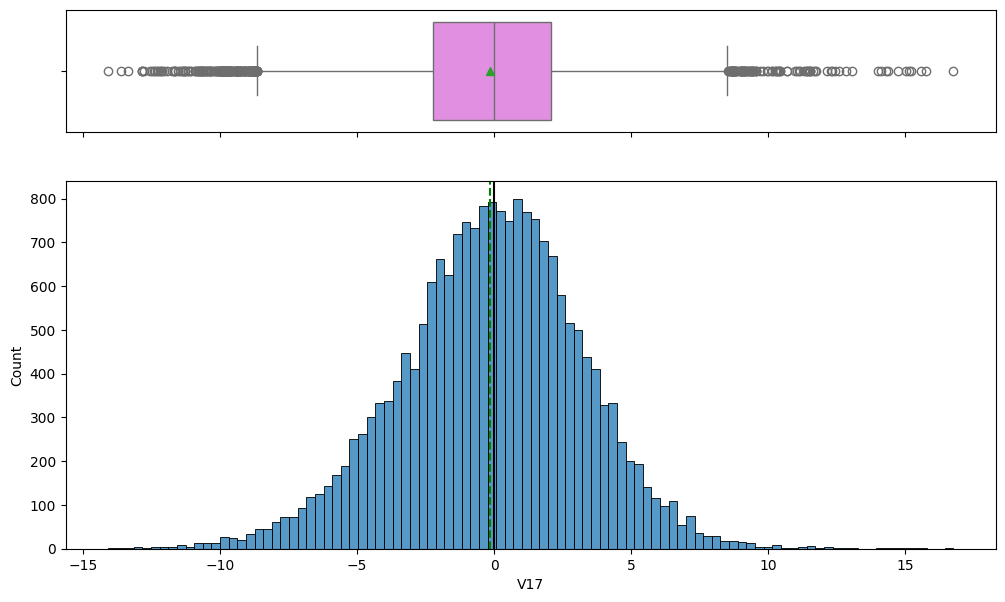

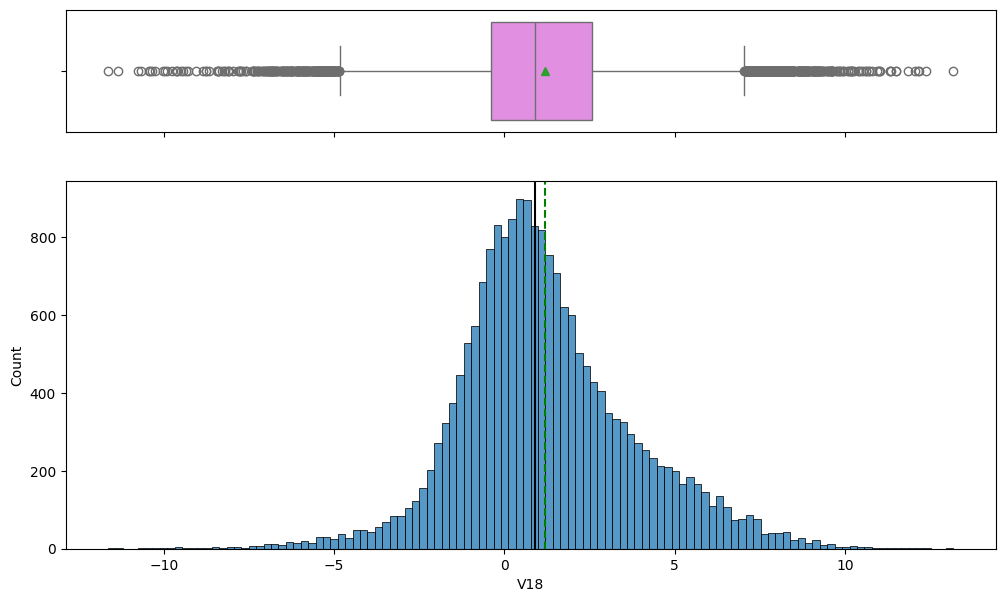

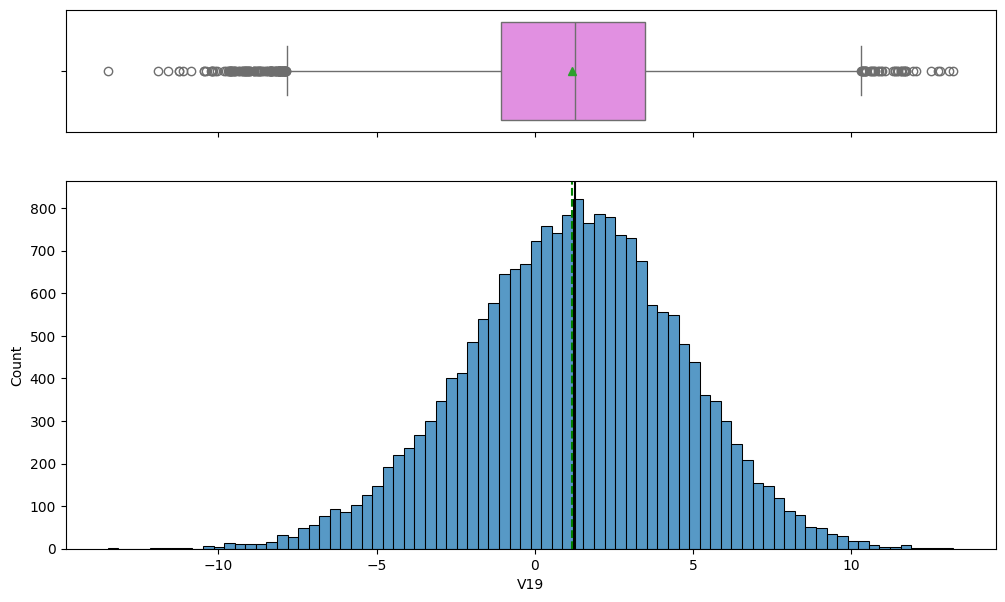

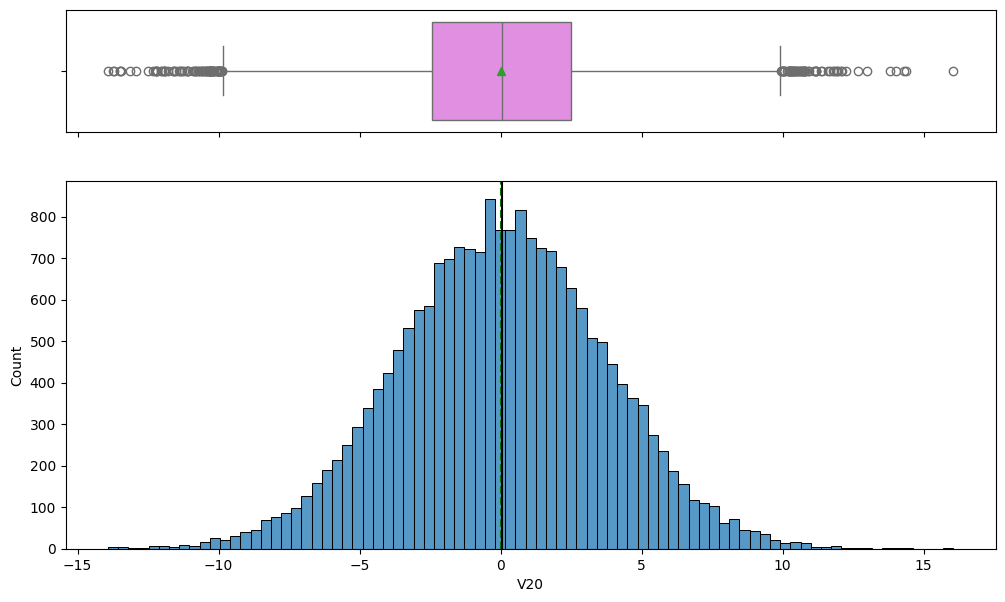

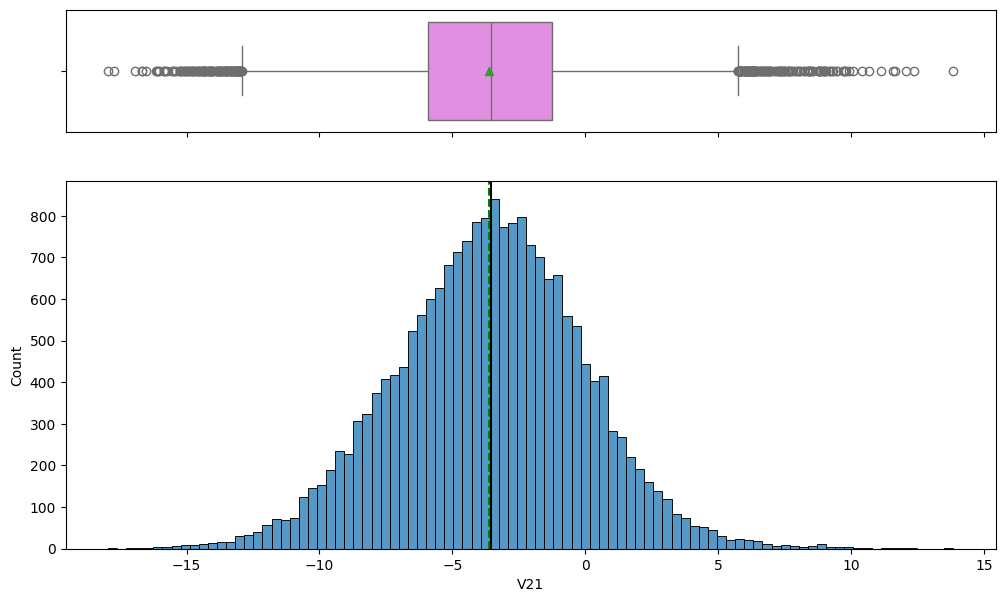

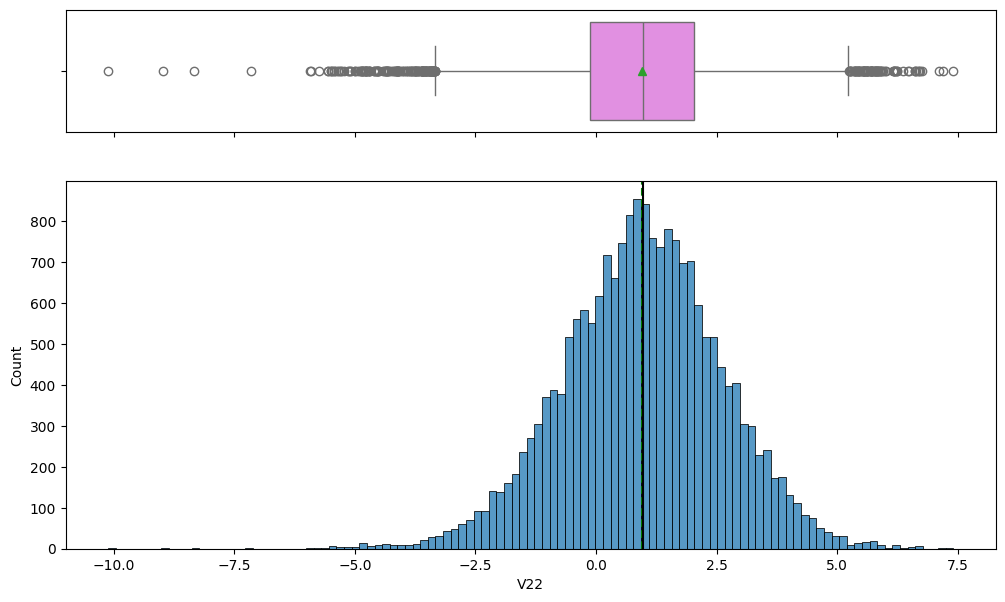

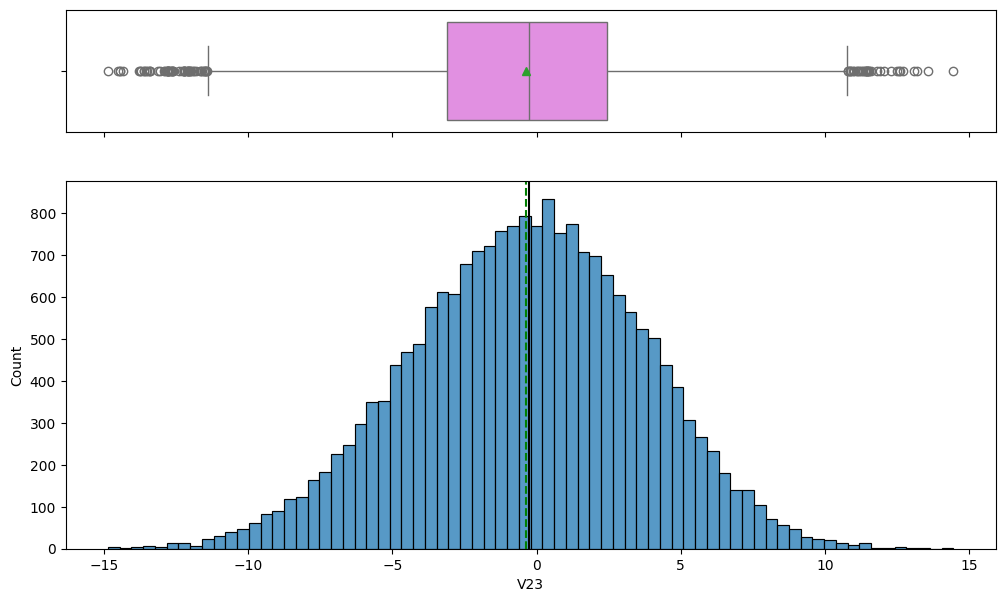

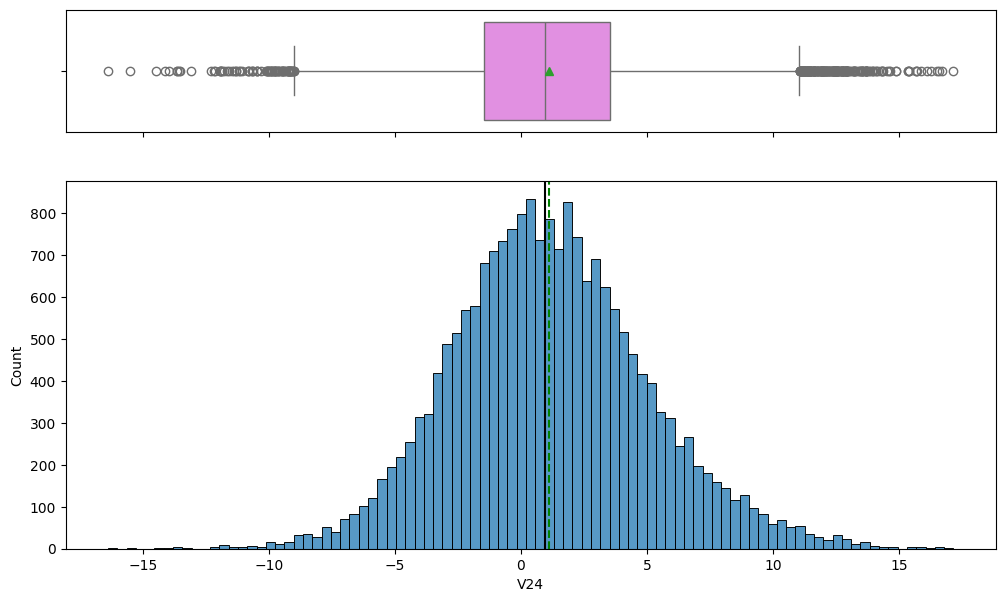

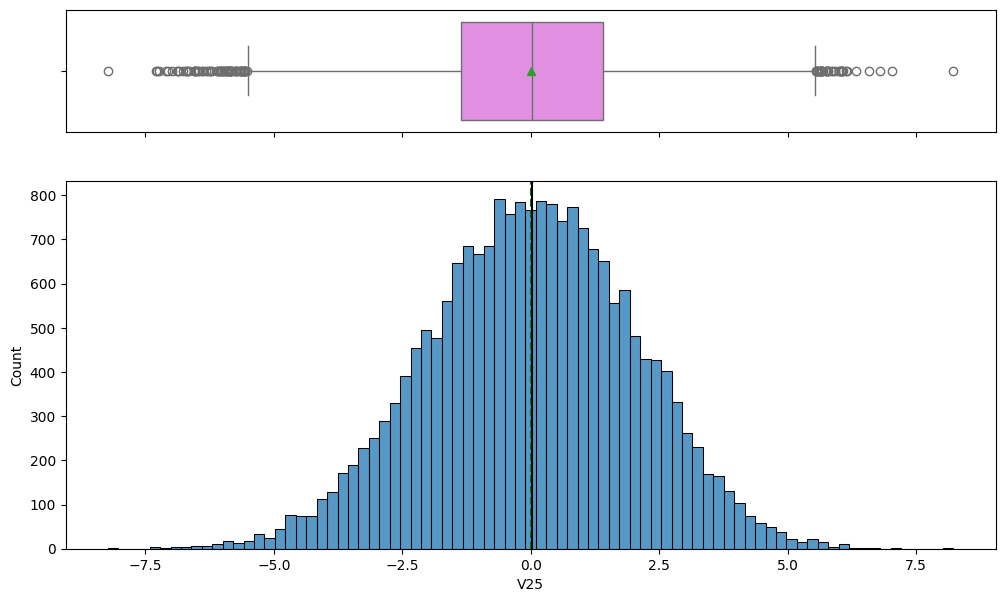

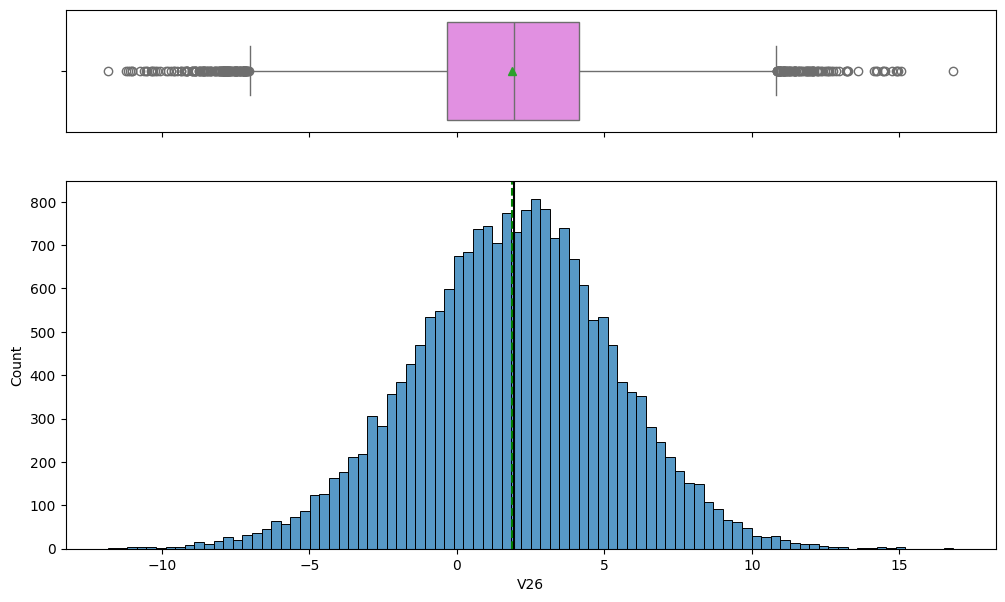

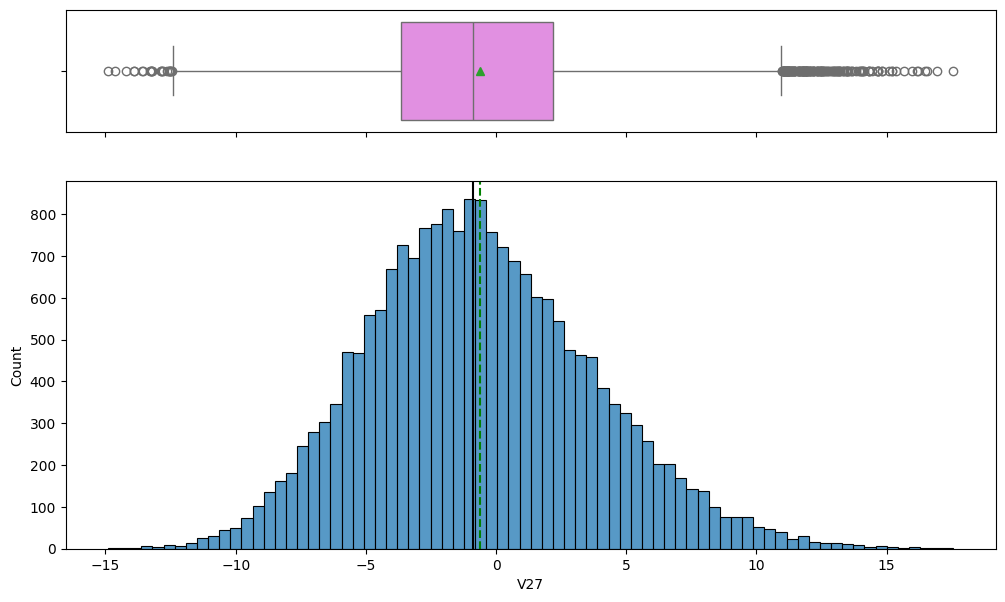

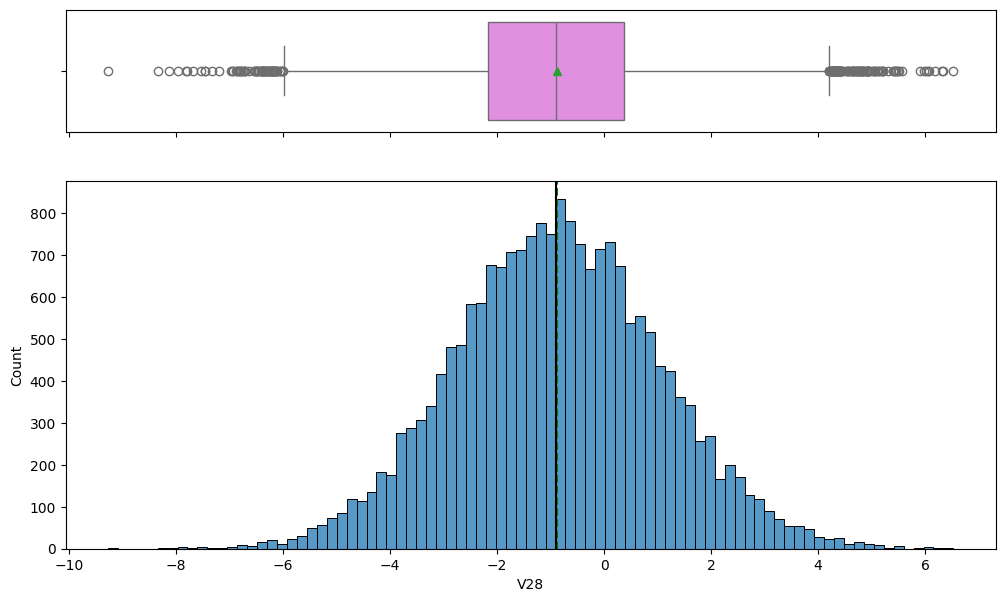

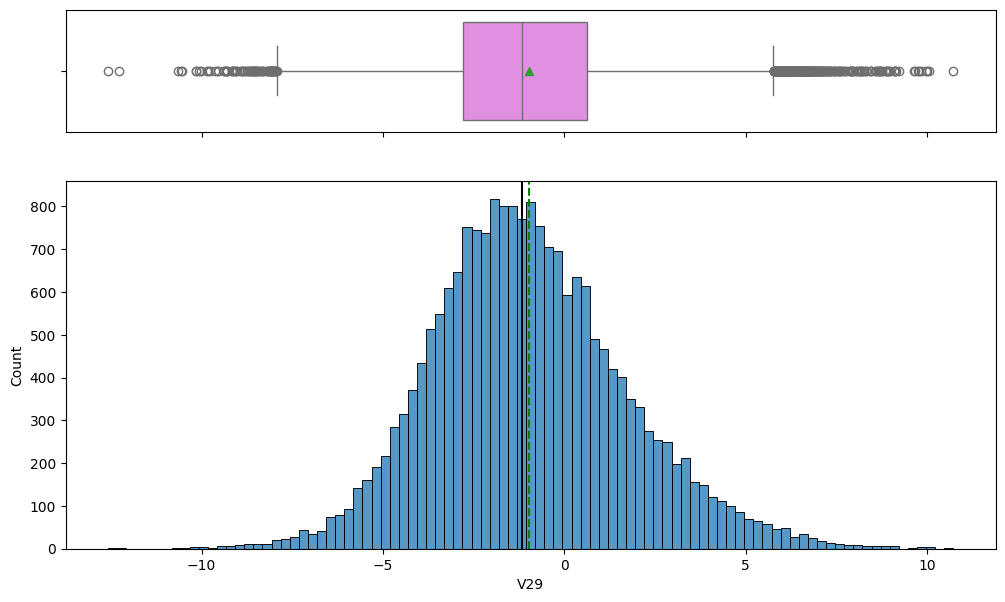

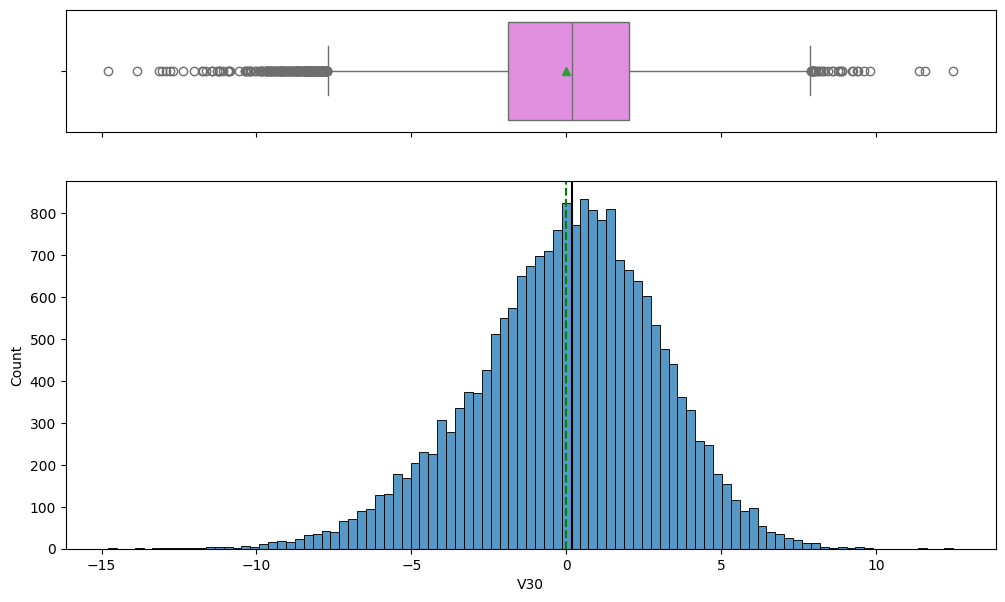

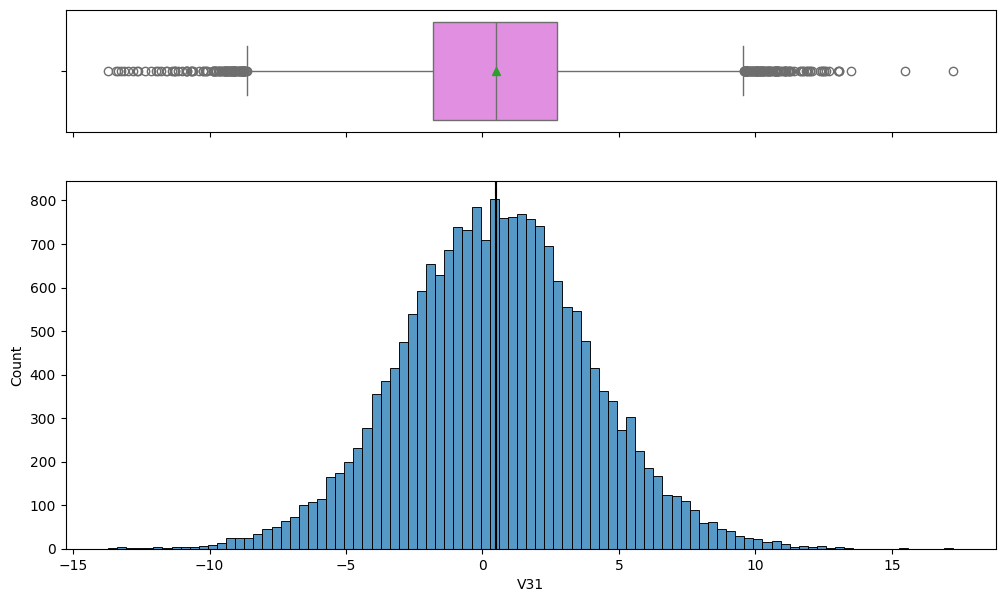

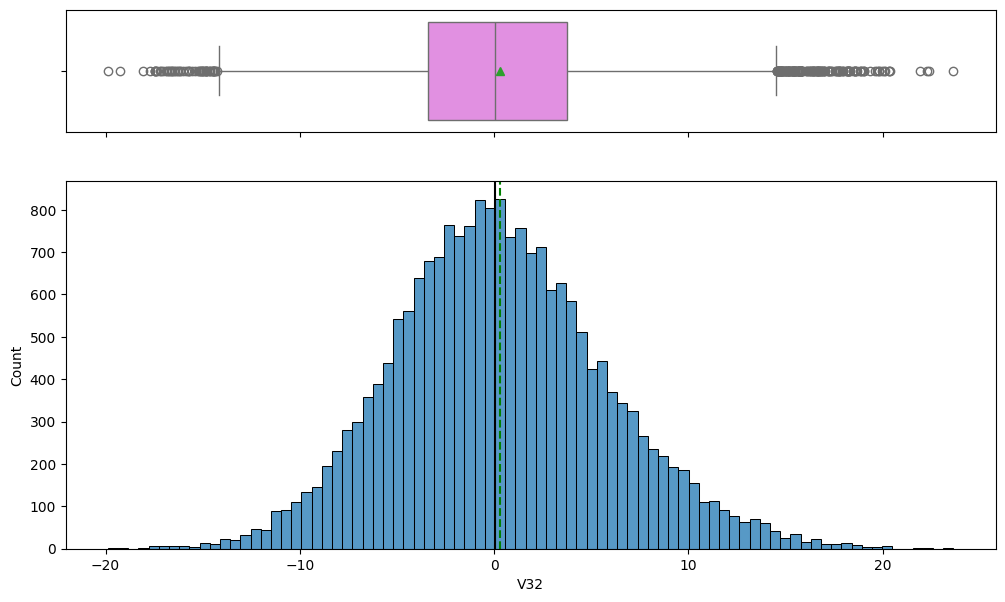

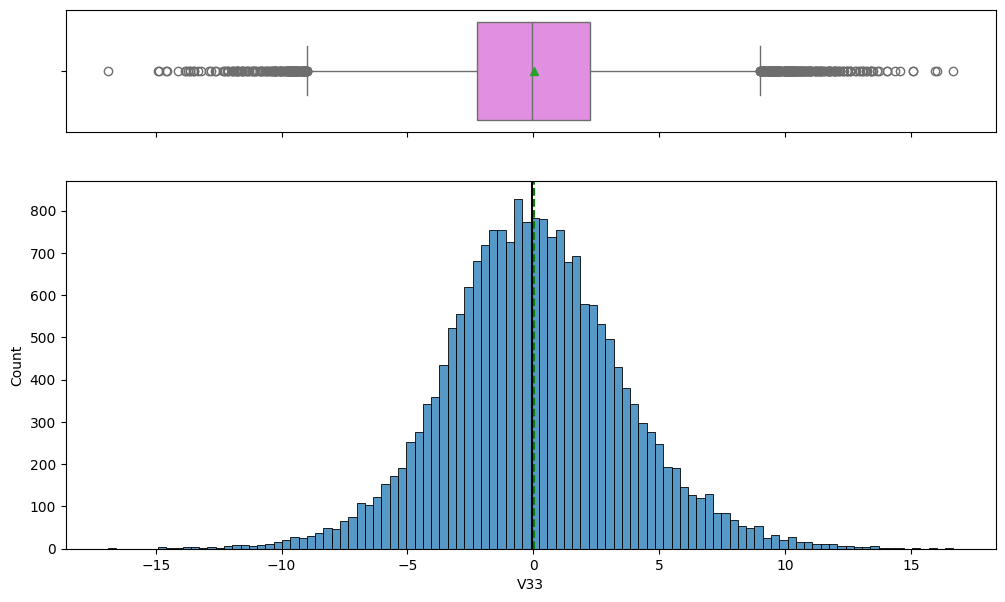

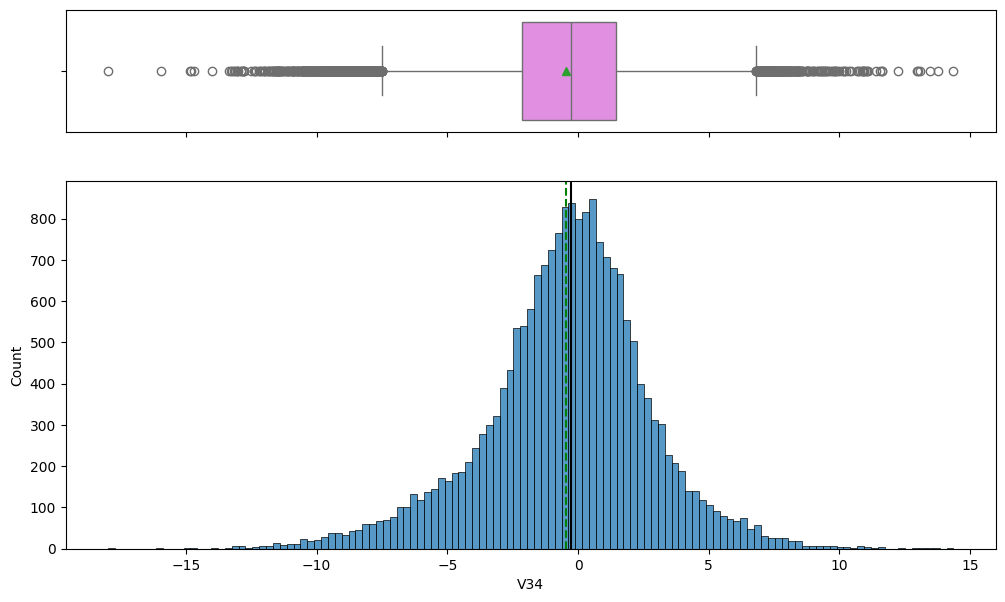

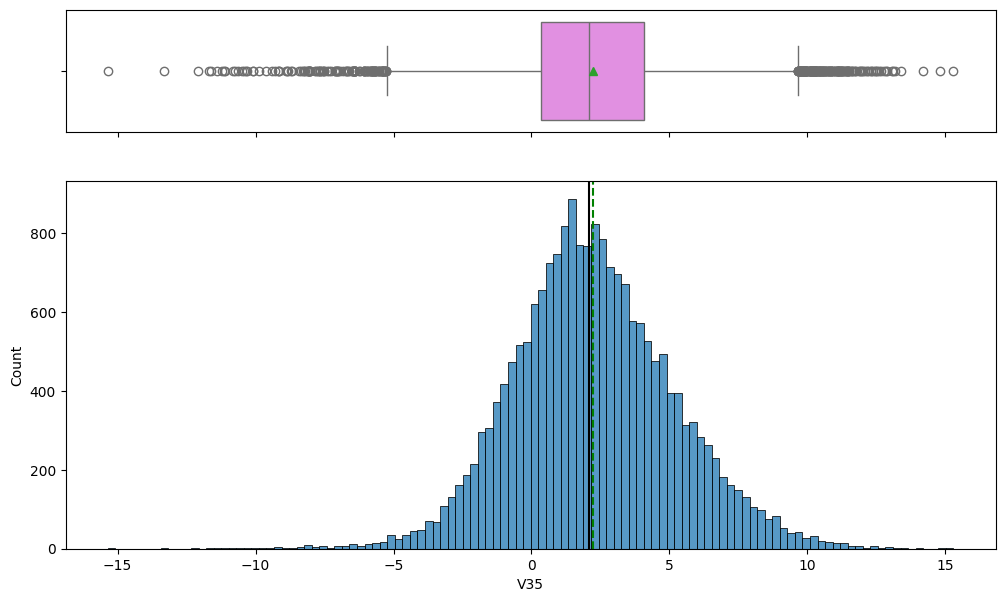

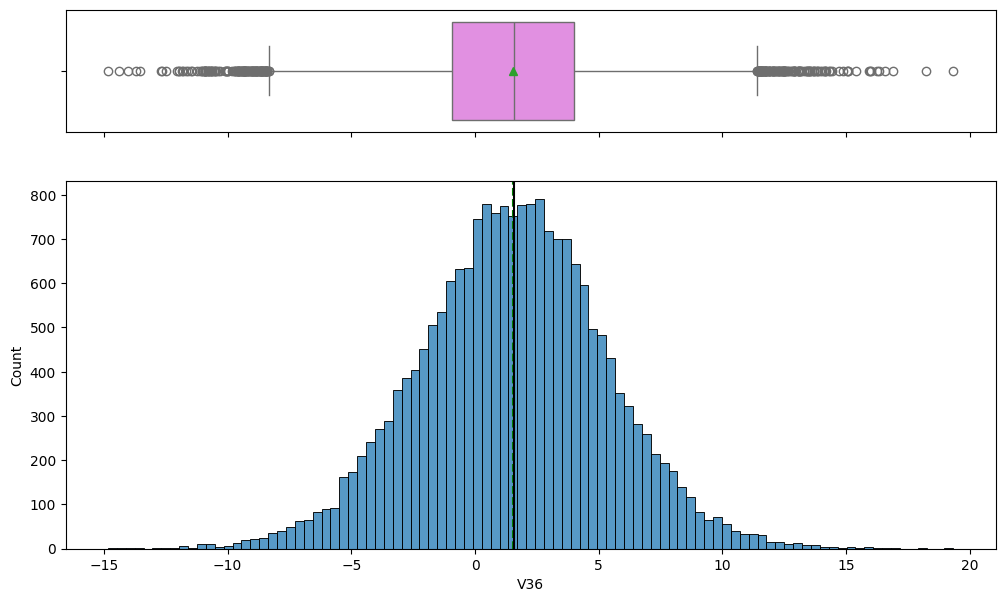

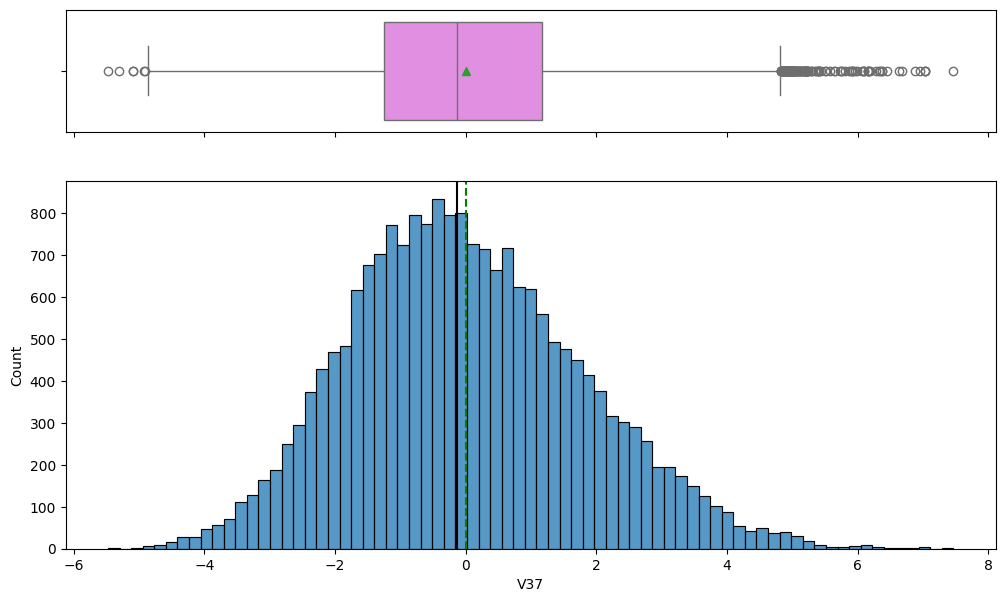

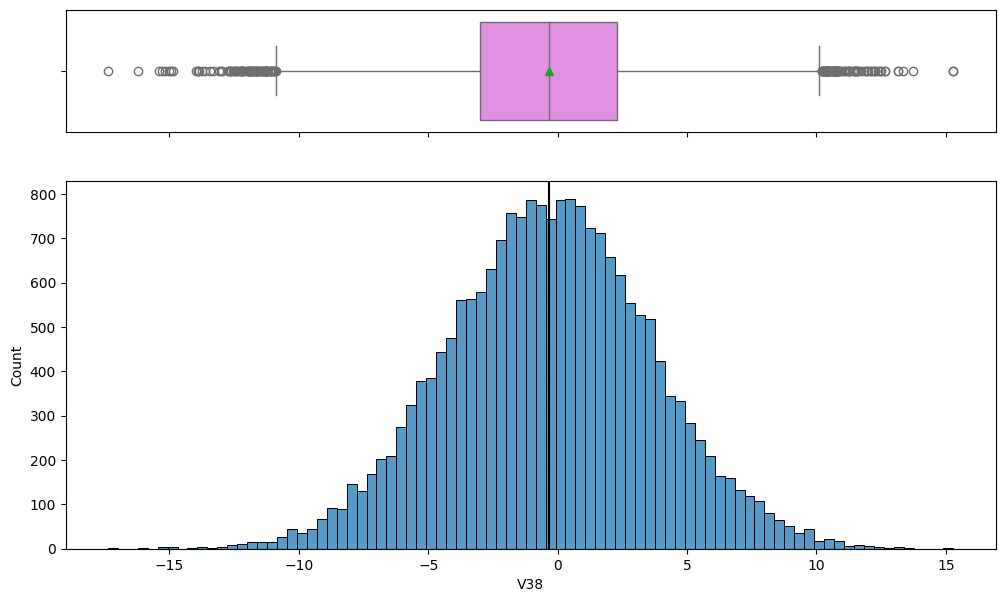

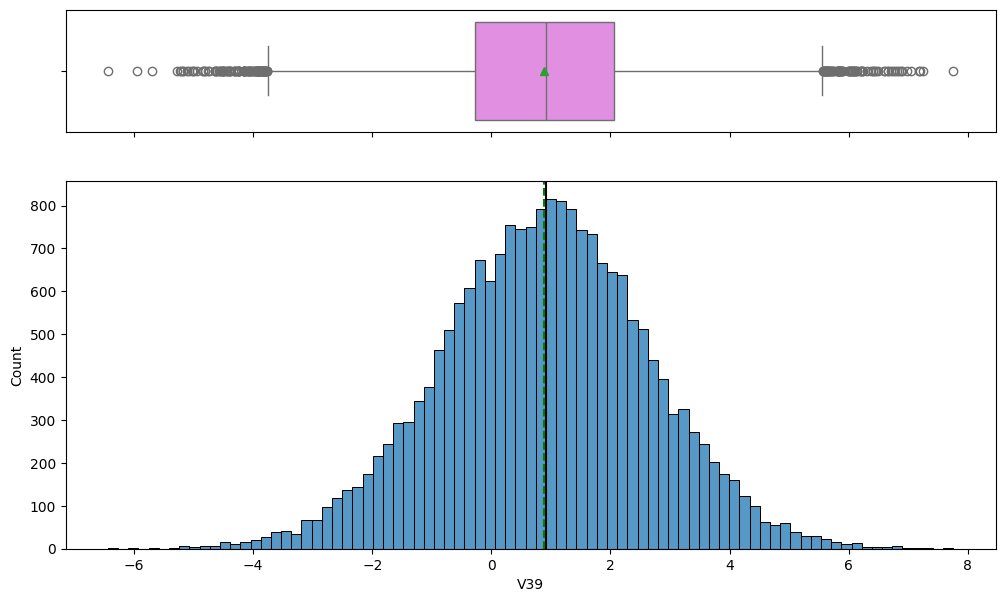

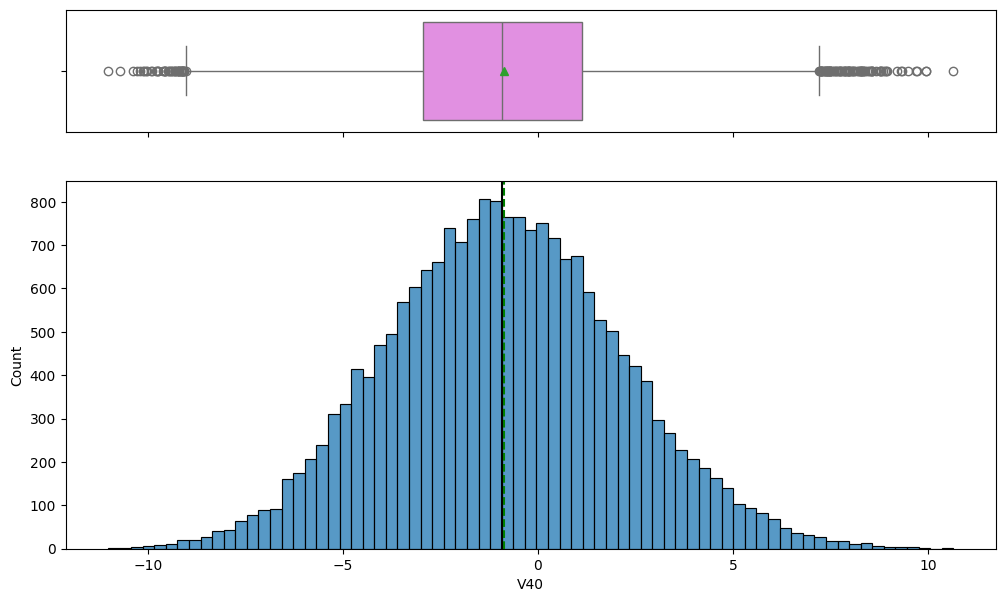

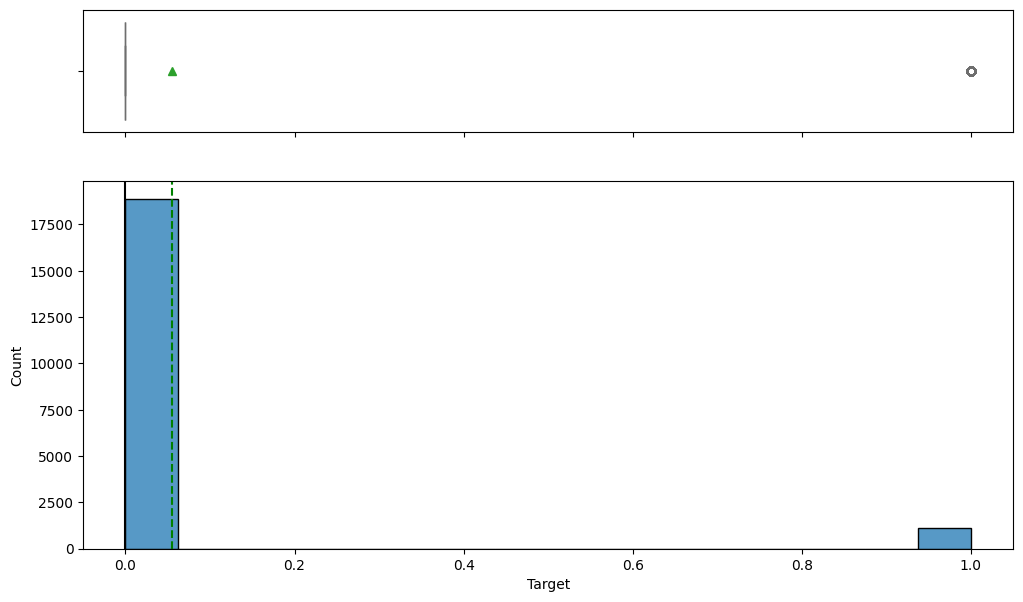

In [244]:
%%time
for feature in data.columns:
    histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None) ## Please change the dataframe name as you define while reading the data

We observe that the majority of columns are fairly normally distributed, but not centered around the mean of zero.  

In [123]:
#%%time
# Attempt to look at pair plots to detect any correlation and if over/undersampling would be useful.
#sns.pairplot(data, hue='Target',diag_kind='hist')

#output: CPU times: user 32min 35s, sys: 6.58 s, total: 32min 41s
#Wall time: 33min 8s
#<seaborn.axisgrid.PairGrid at 0x7ae93a71aa80>
#Buffered data was truncated after reaching the output size limit.

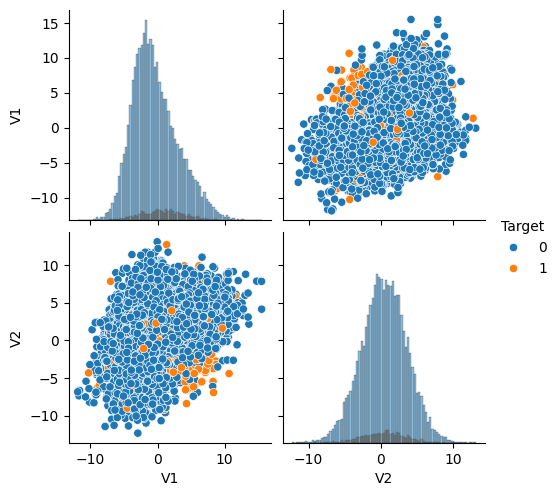

In [124]:
# Attempt to look at pair plots to detect any correlation and if over/undersampling would be useful.
sns.pairplot(data, vars=['V1', 'V2'], hue='Target', diag_kind='hist')

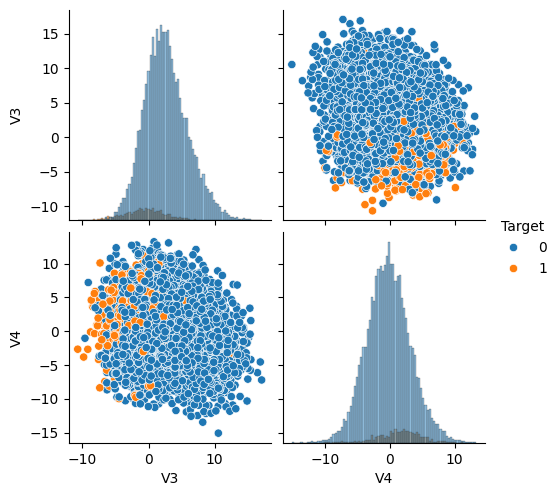

In [125]:
sns.pairplot(data, vars=['V3', 'V4'], hue='Target', diag_kind='hist')

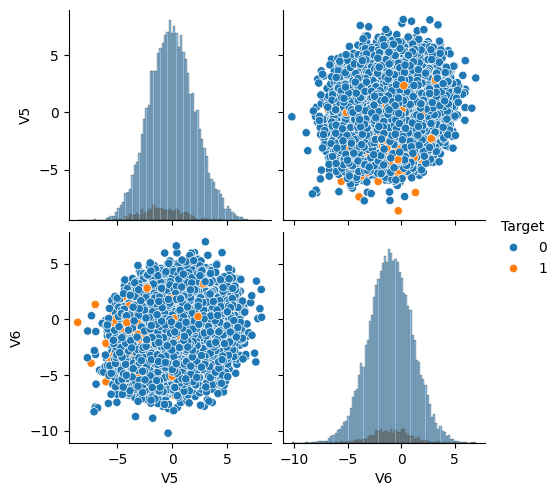

In [126]:
sns.pairplot(data, vars=['V5', 'V6'], hue='Target', diag_kind='hist')

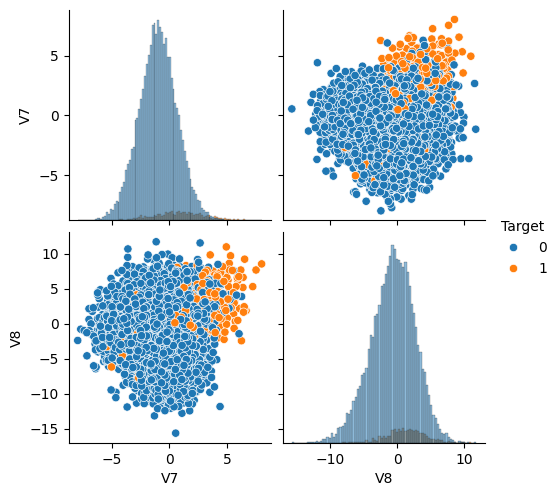

In [127]:
sns.pairplot(data, vars=['V7', 'V8'], hue='Target', diag_kind='hist')

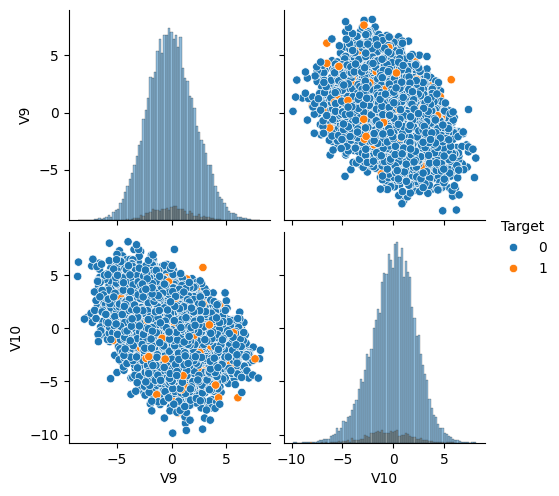

In [128]:
sns.pairplot(data, vars=['V9', 'V10'], hue='Target', diag_kind='hist')

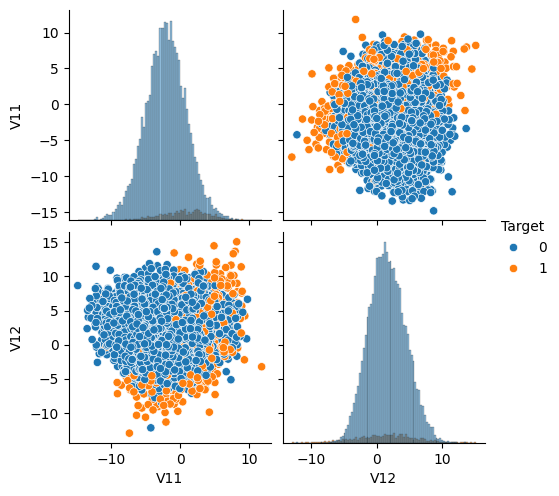

In [129]:
sns.pairplot(data, vars=['V11', 'V12'], hue='Target', diag_kind='hist')

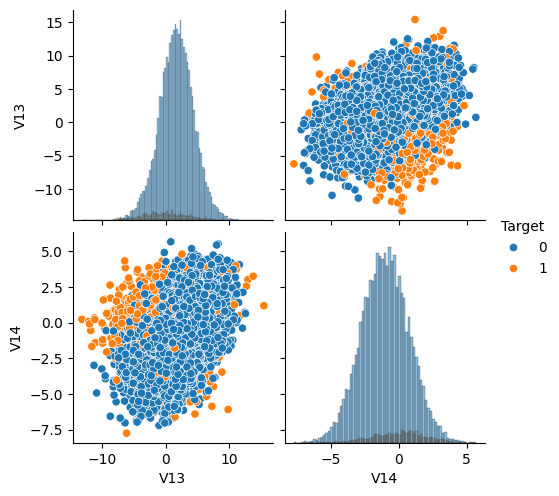

In [130]:
sns.pairplot(data, vars=['V13', 'V14'], hue='Target', diag_kind='hist')

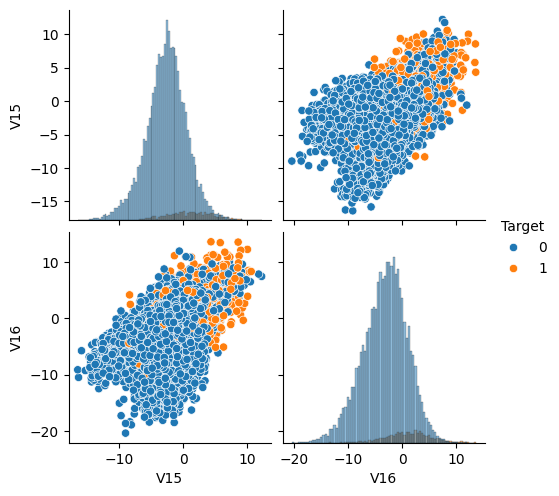

In [131]:
sns.pairplot(data, vars=['V15', 'V16'], hue='Target', diag_kind='hist')

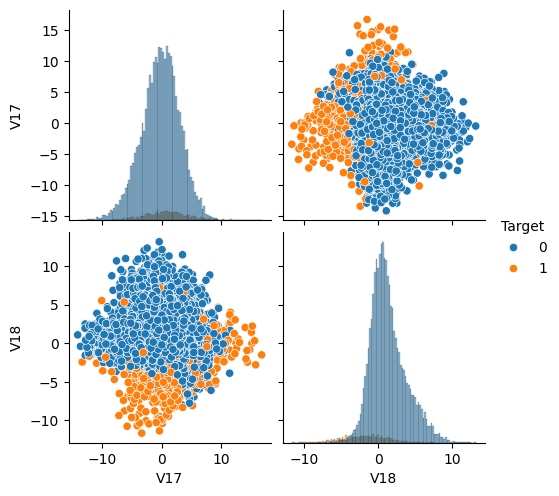

In [132]:
sns.pairplot(data, vars=['V17', 'V18'], hue='Target', diag_kind='hist')

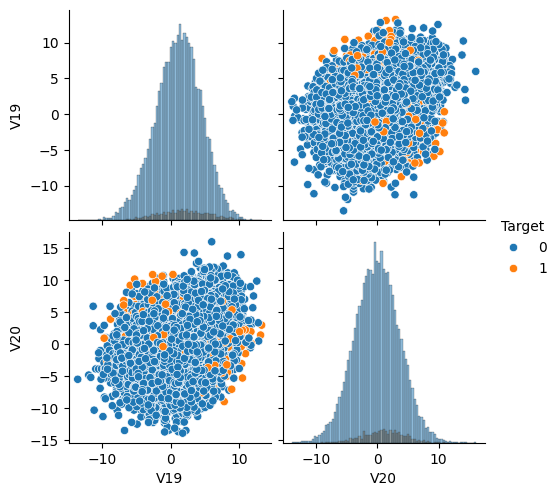

In [133]:
sns.pairplot(data, vars=['V19', 'V20'], hue='Target', diag_kind='hist')

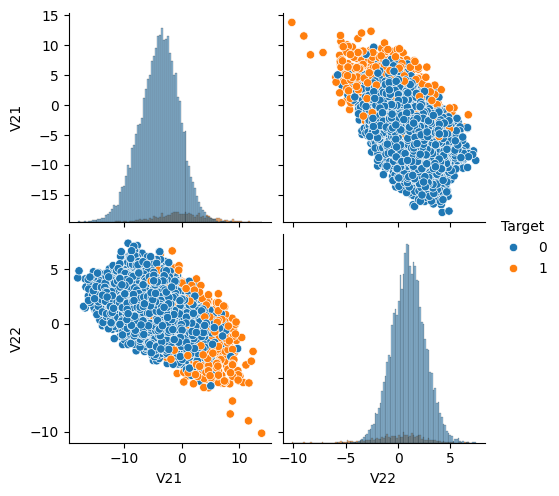

In [134]:
sns.pairplot(data, vars=['V21', 'V22'], hue='Target', diag_kind='hist')

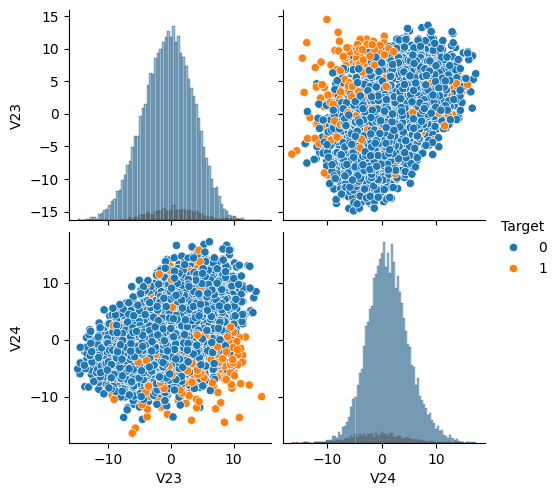

In [135]:
sns.pairplot(data, vars=['V23', 'V24'], hue='Target', diag_kind='hist')

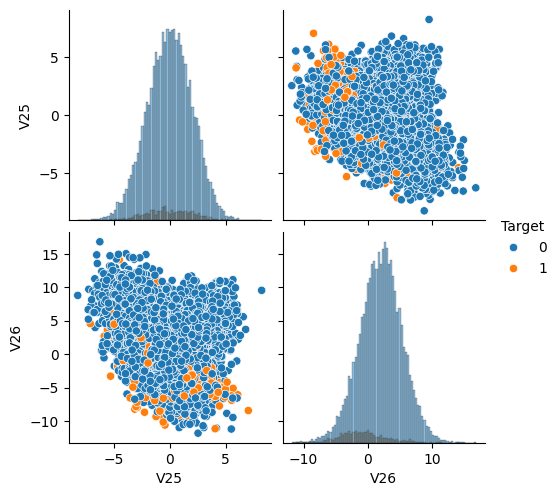

In [136]:
sns.pairplot(data, vars=['V25', 'V26'], hue='Target', diag_kind='hist')

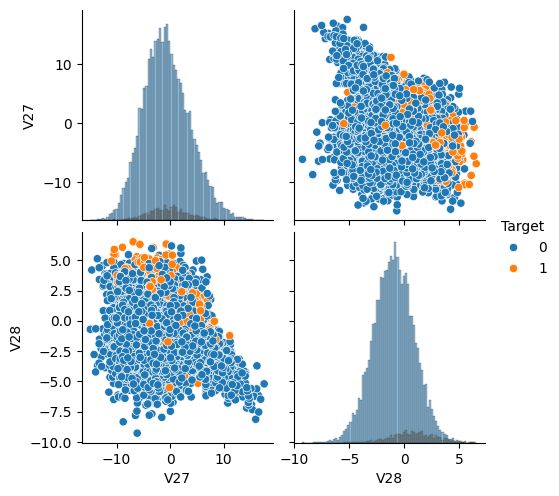

In [137]:
sns.pairplot(data, vars=['V27', 'V28'], hue='Target', diag_kind='hist')

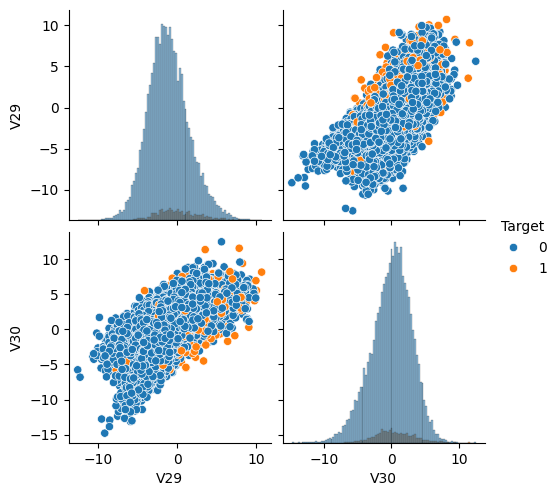

In [138]:
sns.pairplot(data, vars=['V29', 'V30'], hue='Target', diag_kind='hist')

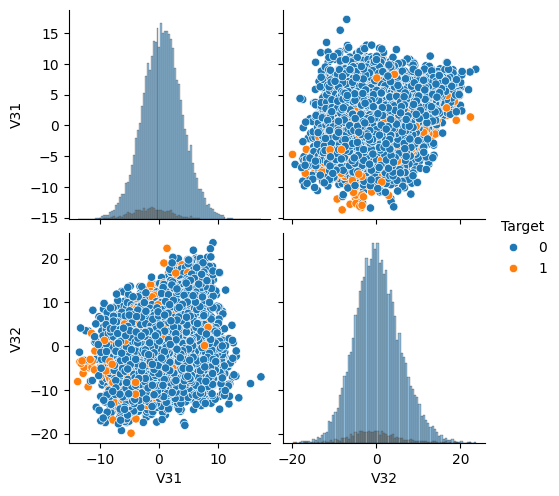

In [139]:
sns.pairplot(data, vars=['V31', 'V32'], hue='Target', diag_kind='hist')

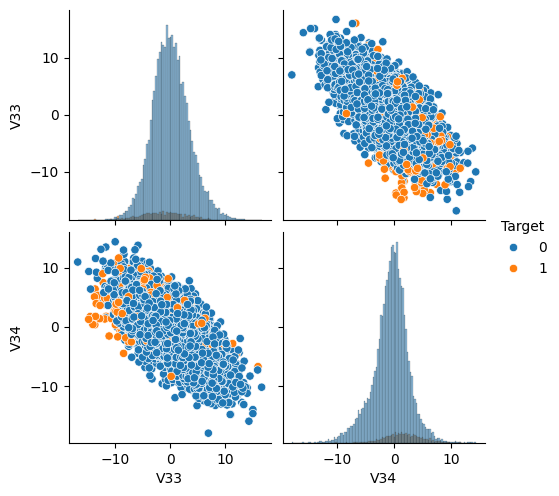

In [140]:
sns.pairplot(data, vars=['V33', 'V34'], hue='Target', diag_kind='hist')

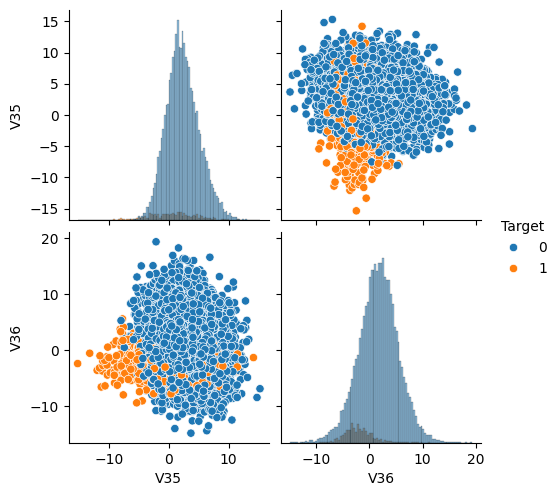

In [141]:
sns.pairplot(data, vars=['V35', 'V36'], hue='Target', diag_kind='hist')

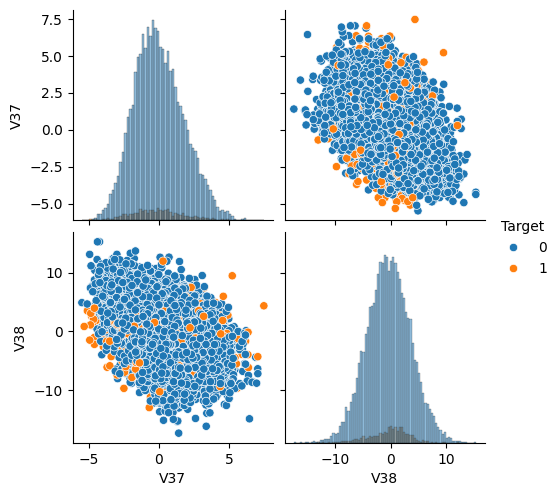

In [142]:
sns.pairplot(data, vars=['V37', 'V38'], hue='Target', diag_kind='hist')

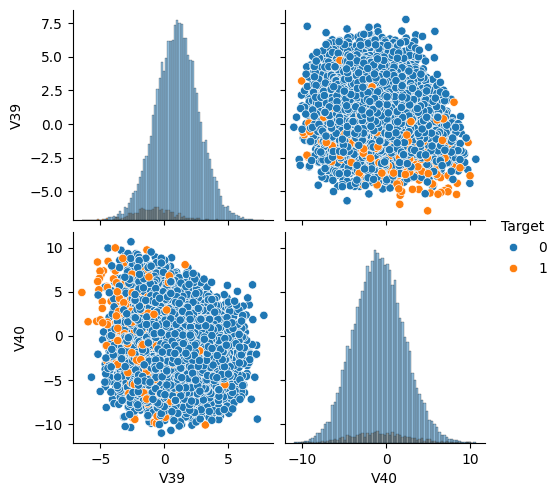

In [143]:
sns.pairplot(data, vars=['V39', 'V40'], hue='Target', diag_kind='hist')

We observe that the majority of the datapoints in these pairplots belong to the "no failure" class.  This class imbalance is a common challenge in classification problems and needs to be addressed during model building to ensure the model can effectively predict the minority class.

### Let's look at the values in target variable:

In [245]:
# Check the class distribution of target variable in training set:
data["Target"].value_counts()

,count
Target,
0,18890
1,1110


In [246]:
# Check the class distribution of target variable in training data:
# Convert counts to percentages and display with formatting
train_distribution = data["Target"].value_counts(normalize=True) * 100
train_distribution

,proportion
Target,
0,94.450
1,5.550


In [247]:
# Check the class distribution of target variable in test set:
data_test["Target"].value_counts()

,count
Target,
0,4718
1,282


In [248]:
# Convert counts to percentages:
test_distribution = data_test["Target"].value_counts(normalize=True) * 100
test_distribution

,proportion
Target,
0,94.360
1,5.640


## Data Pre-processing

In [249]:
# Create target variable y and predictor variables X:
X = data.drop("Target", axis=1)
y = data["Target"]

In [250]:
# Splitting train dataset into training and validation set:
# stratify = y:  ensures that the split preserves the proportion of the target variable y in both training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

In [251]:
# Check number of rows and columns in training set:
X_train.shape

(15000, 40)

In [252]:
# Check number of rows and columns in validation set:
X_val.shape

(5000, 40)

In [253]:
# Divide test data into X_test and y_test:
X_test = data_test.drop("Target", axis=1)
y_test = data_test["Target"]

In [254]:
# Check number of rows and columns of test set:
X_test.shape

(5000, 40)

## Missing value imputation




In [255]:
# Create an instance of the imputer to be used:
# The median is less sensititve to outliers than the mean, and provides a more robust estimate of the center of the data:
imputer = SimpleImputer(strategy="median")

In [256]:
# Fit the imputer on the training data:
imputer.fit(X_train)

# Transform the train, test, and validation data using the fitted imputer:
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)
X_val = imputer.transform(X_val)

In [257]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)
X_val = pd.DataFrame(X_val, columns=X.columns)

Observation:  

To prevent data leakage, you should only fit the imputer on the training data. Then, use that fitted imputer to transform the training, validation, and test sets. This ensures that the imputation is based solely on the training data's characteristics.

In [258]:
# Check that no column has missing values in training, validation or test sets:
X_train.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [259]:
X_val.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [260]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [261]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

### Model Building with original data

Sample Decision Tree model building with original data

In [262]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic regression", LogisticRegression(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Logistic regression: 0.4927566553639709
Bagging: 0.7210807301060529
Random Forest: 0.7235192266070268
GBM: 0.7066661857008874
Xgboost: 0.801644902965154
dtree: 0.6982829521679532

Validation Performance:

Logistic regression: 0.4856115107913669
Bagging: 0.7302158273381295
Random Forest: 0.7266187050359713
GBM: 0.7230215827338129
Xgboost: 0.841726618705036
dtree: 0.7050359712230215


We observe that the XGboost model delivers the highest recall score of 0.84 in the validation set, compared to 0.80 on the training set.

Generally, you would expect a model's performance (including recall) to be slightly better on the training set than on the validation set, as the model has been trained on the training data.

When the recall score is higher on the validation set, it can sometimes indicate:

The validation set is "easier" for the model: It might contain instances of the positive class that are more clearly separable from the negative class compared to the training set. This could happen by chance, especially with a relatively small number of positive cases (as seen in the class distribution).
Random chance: With the class imbalance, even a small number of correct predictions in the validation set could lead to a higher recall percentage if the total number of actual positive cases in the validation set is also small.
Potential for a lucky split: While you used stratify=y to maintain the proportion of the target variable, there might still be some differences in the characteristics of the positive class instances between the train and validation sets that favor the model's predictions on the validation set.
It's less likely to be a sign of overfitting in this specific scenario, as overfitting typically leads to lower performance on unseen data (like the validation set).

Given the class imbalance, it's a good idea to continue with the notebook's plan of exploring oversampling and undersampling techniques to see if they can help improve the model's ability to identify the minority class consistently across different data splits.

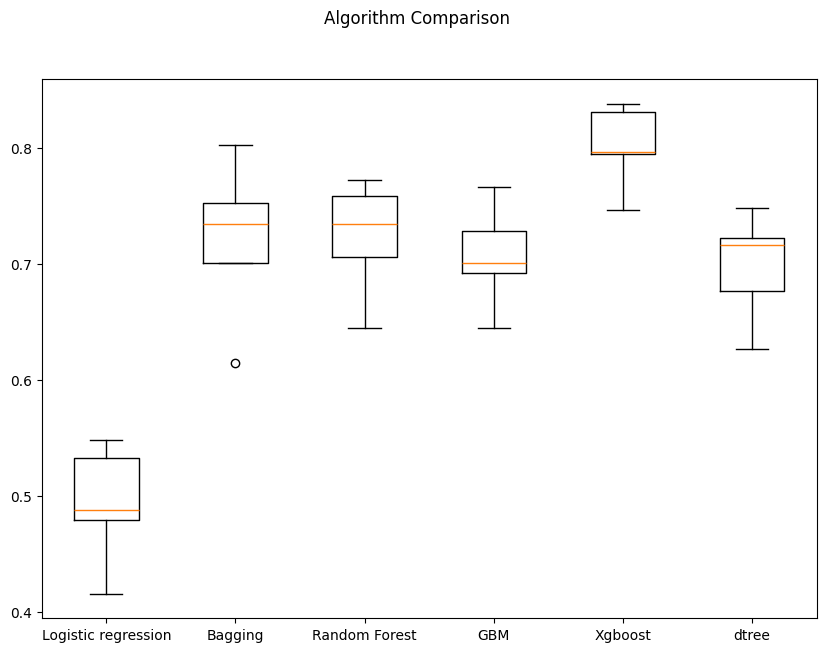

In [263]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

We observe that the top three scoring algorithms are XGboost, Random Forest, and Bagging Classifiers.

### Model Building with Oversampled data


 Let's see if we can get higher scores using over- and under sampling of training data.

In [264]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [265]:
print("Before Oversampling count of yes: {}".format(sum(y_train == 1)))
print("Before Oversampling count of no: {}".format(sum(y_train == 0)))
print("\n")
print("After Oversampling count of yes:{}".format(sum(y_train_over == 1)))
print("After Oversampling count of no: {}".format(sum(y_train_over == 0)))

Before Oversampling count of yes: 832
Before Oversampling count of no: 14168


After Oversampling count of yes:14168
After Oversampling count of no: 14168


In [266]:
print("After Oversampling the shape of X_train:", X_train_over.shape)
print("After Oversampling the shape of y_train:", y_train_over.shape)

After Oversampling the shape of X_train: (28336, 40)
After Oversampling the shape of y_train: (28336,)


In [267]:
%%time
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic regression", LogisticRegression(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XG Boosting", XGBClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
## Complete the code to append remaining 4 models in the list models

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )  ## Complete the code to build models on oversampled data
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over,y_train_over)## Complete the code to build models on oversampled data
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Logistic regression: 0.883963699328486
Bagging: 0.9762141471581656
Random Forest: 0.9839075260047615
Gradient Boosting: 0.9256068151319724
XG Boosting: 0.9891305241357218
Decision Tree: 0.9720494245534969

Validation Performance:

Logistic regression: 0.8489208633093526
Bagging: 0.8345323741007195
Random Forest: 0.8489208633093526
Gradient Boosting: 0.8776978417266187
XG Boosting: 0.8669064748201439
Decision Tree: 0.7769784172661871
CPU times: user 11min 35s, sys: 430 ms, total: 11min 36s
Wall time: 11min 32s


Performance of this model on training set varies between 0.88 to 0.98, which is an improvement from the model built on the original dataset
Performance on the training set improved but the model is not able to replicate the same for the validation set, which indicates that the model is overfitting.
Let's try regularization to see if overfitting can be reduced.  

We'll use the regularization technique of data augmentation to address any class imbalances.

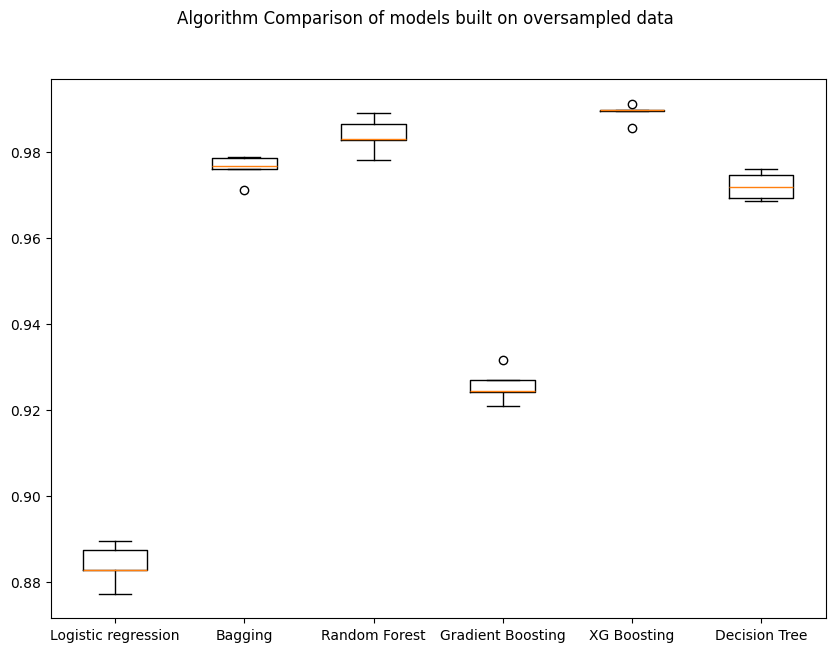

In [268]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10,7))

fig.suptitle("Algorithm Comparison of models built on oversampled data")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with Undersampled data

In [269]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [270]:
print("Before Undersampling count of yes: {}".format(sum(y_train == 1)))
print("Before Undersampling count of no: {}".format(sum(y_train == 0)))
print("\n")
print("After Undersampling count of yes:{}".format(sum(y_train_un == 1)))
print("After Undersampling count of no: {}".format(sum(y_train_un == 0)))

Before Undersampling count of yes: 832
Before Undersampling count of no: 14168


After Undersampling count of yes:832
After Undersampling count of no: 832


In [271]:

print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

After UnderSampling, the shape of train_X: (1664, 40)
After UnderSampling, the shape of train_y: (1664,) 



In [272]:
%%time
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic regression", LogisticRegression(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XG Boosting", XGBClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
## Complete the code to append remaining 4 models in the list models

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold
    )  ## Complete the code to build models on undersampled data
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)## Complete the code to build models on undersampled data
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))



Cross-Validation performance on training dataset:

Logistic regression: 0.8726138085275232
Bagging: 0.8641945025611427
Random Forest: 0.9038669648654498
Gradient Boosting: 0.8978572974532861
XG Boosting: 0.9014717552846114
Decision Tree: 0.8617776495202367

Validation Performance:

Logistic regression: 0.8525179856115108
Bagging: 0.8705035971223022
Random Forest: 0.8920863309352518
Gradient Boosting: 0.8884892086330936
XG Boosting: 0.89568345323741
Decision Tree: 0.841726618705036
CPU times: user 37.6 s, sys: 64.7 ms, total: 37.6 s
Wall time: 35.4 s


Performance of this model trained on data with undersampling varies between 0.86 to 0.90, while validation performance ranges between 0.84 and 0.89.

This means this model is not over- nor underfitted. The overal recall score performance among the various algorithm classifiers is quite good.

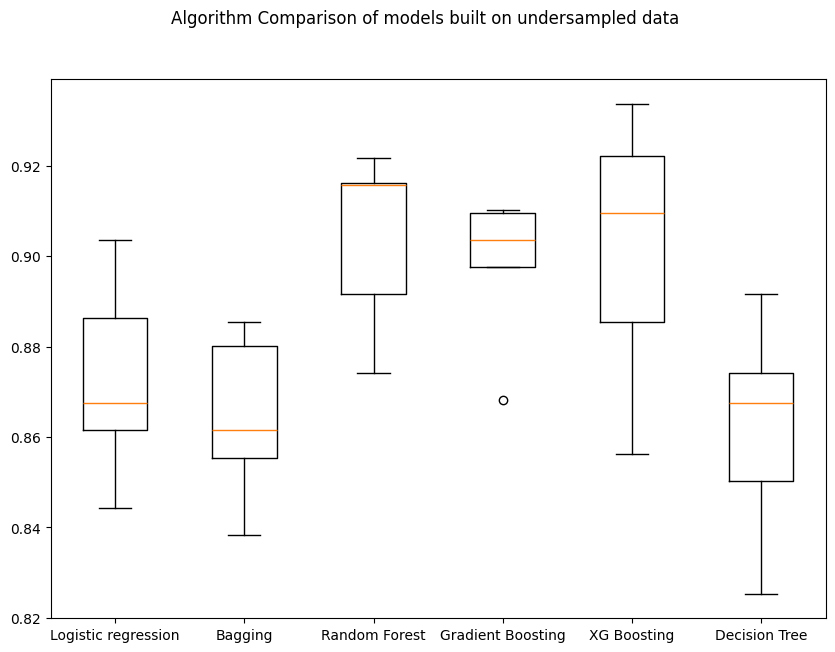

In [273]:
# Plotting boxplots for CV scores of all models defined above
# Create a boxplot to check model performances on undersampled data:
fig = plt.figure(figsize=(10,7))

fig.suptitle("Algorithm Comparison of models built on undersampled data")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

After looking at performance of all the models, let's decide which models can further improve with hyperparameter tuning.  XG boost is the top performing model, but takes a long time to run.  We'll try to hypertune the second highest performing model: Random Forest.

## HyperparameterTuning

### Sample Parameter Grids

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

### Sample tuning method for Random Forest with original data

In [274]:
%%time

# defining tuned Random Forest model:
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 250, 'min_samples_leaf': np.int64(1), 'max_samples': np.float64(0.6), 'max_features': 'sqrt'} with CV score=0.6996248466921577:
CPU times: user 38.2 s, sys: 535 ms, total: 38.7 s
Wall time: 12min 25s


Cross Validation score refers to the average Recall score achieved by the model with that set of hyperparameters across the 5 cross validation folds.

In this situation, the lower CV score suggests that the untuned model's performance on the initial validation set might have been a bit optimistic, and the tuned model's average performance across different training subsets is lower. You would typically use the CV score from tuning to select the best hyperparameters and then evaluate the final model with those hyperparameters on the separate test set to get a more reliable estimate of its performance on truly unseen data.

In [276]:
# Create new pipeline with best parameters:
RF_tuned = RandomForestClassifier(
    random_state=1,
    max_features= 'sqrt',
    max_samples= 0.6,
    n_estimators= 250,
    min_samples_leaf=1
)

RF_tuned.fit(X_train, y_train)


RandomForestClassifier(max_samples=0.6, n_estimators=250, random_state=1)

In [277]:
# Check tuned Random Forest training performance:
RF_tuned_train_perf = model_performance_classification_sklearn(RF_tuned, X_train, y_train)
RF_tuned_train_perf

,Accuracy,Recall,Precision,F1
0,0.995,0.909,1.000,0.952


In [278]:
# Check tuned Random Forest validation performance:
RF_tuned_val_perf = model_performance_classification_sklearn(RF_tuned, X_val, y_val)
RF_tuned_val_perf

,Accuracy,Recall,Precision,F1
0,0.983,0.712,0.985,0.827


### Sample tuning method for Random Forest with oversampled data

In [279]:
%%time

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 300, 'min_samples_leaf': np.int64(1), 'max_samples': np.float64(0.6), 'max_features': 'sqrt'} with CV score=0.9815078165615898:
CPU times: user 1min 7s, sys: 2.2 s, total: 1min 9s
Wall time: 21min 22s


In [281]:
# Creat new pipeline with best parameters:
RF_oversample_tuned = RandomForestClassifier(
    random_state=1,
    max_samples= 0.6,
    max_features= 'sqrt',
    n_estimators= 300,
    min_samples_leaf=1
)

RF_oversample_tuned.fit(X_train_over, y_train_over)

RandomForestClassifier(max_samples=0.6, n_estimators=300, random_state=1)

In [282]:
RF_oversample_tuned_train_perf = model_performance_classification_sklearn(RF_oversample_tuned, X_train_over, y_train_over)
RF_oversample_tuned_train_perf

,Accuracy,Recall,Precision,F1
0,1.000,0.999,1.000,1.000


In [284]:
RF_oversample_tuned_val_perf = model_performance_classification_sklearn(RF_oversample_tuned, X_val, y_val)
RF_oversample_tuned_val_perf

,Accuracy,Recall,Precision,F1
0,0.988,0.860,0.926,0.892


### Sample tuning method for Random Forest with undersampled data

In [285]:
%%time

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 250, 'min_samples_leaf': np.int64(1), 'max_samples': np.float64(0.6), 'max_features': 'sqrt'} with CV score=0.8978140105331505:
CPU times: user 3.22 s, sys: 65.3 ms, total: 3.28 s
Wall time: 56.2 s


In [286]:
# Create new pipeline with best parameters:
RF_undersample_tuned = RandomForestClassifier(
    random_state=1,
    max_features= 'sqrt',
    max_samples=0.6,
    n_estimators=250,
    min_samples_leaf=1
)

RF_undersample_tuned.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.6, n_estimators=250, random_state=1)

In [287]:
RF_undersample_tuned_train_perf = model_performance_classification_sklearn(RF_undersample_tuned, X_train_un, y_train_un)
RF_undersample_tuned_train_perf


,Accuracy,Recall,Precision,F1
0,0.988,0.977,0.999,0.988


In [291]:
RF_undersample_tuned_val_perf = model_performance_classification_sklearn(RF_undersample_tuned, X_val, y_val)
RF_undersample_tuned_val_perf

,Accuracy,Recall,Precision,F1
0,0.944,0.885,0.496,0.636


## Model performance comparison and choosing the final model

In [289]:
# Let's compare above three training performances and choose the final model:
RF_model_train_comparison_df = pd.concat(

    [
          RF_tuned_train_perf.T,
          RF_oversample_tuned_train_perf.T,
          RF_undersample_tuned_train_perf.T,
    ],
    axis=1,

)

RF_model_train_comparison_df.columns = ["RF_tuned", "RF_oversample_tuned", "RF_undersample_tuned"]
print("Random Forest Training performance comparisons:")
RF_model_train_comparison_df

Random Forest Training performance comparisons:


,RF_tuned,RF_oversample_tuned,RF_undersample_tuned
Accuracy,0.995,1.000,0.988
Recall,0.909,0.999,0.977
Precision,1.000,1.000,0.999
F1,0.952,1.000,0.988


In [292]:
# Let's compare the three validation set performances:
RF_model_val_comparison_df = pd.concat(
    [
          RF_tuned_val_perf.T,
          RF_oversample_tuned_val_perf.T,
          RF_undersample_tuned_val_perf.T
    ],
    axis=1,
)

RF_model_val_comparison_df.columns = ["RF_tuned", "RF_oversample_tuned", "RF_undersample_tuned"]
print("Random Forest Validation performance comparisons:")
RF_model_val_comparison_df

Random Forest Validation performance comparisons:


,RF_tuned,RF_oversample_tuned,RF_undersample_tuned
Accuracy,0.983,0.988,0.944
Recall,0.712,0.860,0.885
Precision,0.985,0.926,0.496
F1,0.827,0.892,0.636


We observe that the tuned Random Forest undersampled model delivers the highest Recall score of 0.88 in the validation performance comparison.

### Test set final performance

## Pipelines to build the final model


In [297]:
# Create new pipeline with best parameters:
RF_undersample_tuned = RandomForestClassifier(
    random_state=1,
    max_features= 'sqrt',
    max_samples=0.6,
    n_estimators=250,
    min_samples_leaf=1
)


RF_undersample_tuned.fit(X_test, y_test)

RandomForestClassifier(max_samples=0.6, n_estimators=250, random_state=1)

In [298]:
# The best performing model we found is the tuned Random Forest model with undersampling:
RF_undersample_tuned_test_perf = model_performance_classification_sklearn(RF_undersample_tuned, X_test, y_test)
RF_undersample_tuned_test_perf

,Accuracy,Recall,Precision,F1
0,0.993,0.879,1.000,0.936


We observe that the recall score on the test set is 0.87, which is close to the score of 0.88 on the validation set.  This model is expected to perform well on completely new, unseen data, and will be effective in identifying generator failures.

# Business Insights and Conclusions

We evaluated the performance of one of the best performing models we identified in this project, which is the Random Forest model trained on undersampled data, using the test set (X_test and y_test).

We found a recall score of 0.87, which means this model is expected to perform well on completely new, unseen data, and will be effective in identifying generator failures for ReneWind.